<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg" align="left" width="45%">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.878 · Trabajo de Fin de Máster · LSTM</p>
<p style="margin: 0; text-align:right;">2025-2 · Máster universitario en Ciencia de datos</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Marcos Rodríguez Soler</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# Preprocesamiento de los datos para el modelo _LSTM_

En el presente _notebook_ se lleva a cabo el entrenamiento de la red neuronal de celdas **LSTM** tanto para el conjunto de datos entero como para los múltiples _clusters_ del _dataset_ global. El flujo de trabajo se asemeja al de los otros modelos ya entrenados, donde primero se calculan un conjunto de variables de ventana móvil para incorporar la noción de secuencialidad en los datos que se introducen en la red neuronal, y se crean los conjuntos de entrenamiento, de prueba y de validación. A diferencia de los otros modelos del trabajo, LSTM requiere valores normalizados para estabilizar el entrenamiento y evitar fenómenos como la explosión y la desaparición del gradiente, por lo que luego se aplica un escalado _MinMax_ a los datos secuenciados. Acto seguido, se optimizan algunos de los hiperparámetros más relevantes del modelo LSTM, y continuadamente se entrena la red con la combinación de parámetros que minimiza el RMSE del modelo en el conjunto de validación. Finalmente, se evalúa el rendimiento del algoritmo en el conjunto de prueba y se calculan las métricas de evaluación del error.

La generación de los múltiples conjuntos que se utilizan para entrenar la red LSTM se lleva a cabo de la misma forma que en el modelo **XGBoost**, de manera que el primer 80% de cada serie temporal se utiliza para formar el conjunto de aprendizaje, y el 20% restante para confeccionar el conjunto de prueba. Asimismo, en este caso también se ha decidido crear un conjunto de validación formado por el 20% más reciente de la fracción de entrenamiento de cada serie temporal. En este caso, el conjunto de validación también sirve para reducir el sobreajuste del modelo y mejorar su capacidad generalizadora.

Las redes neuronales se entrenan por épocas, donde cada una se corresponde a una pasada completa del conjunto de entrenamiento por la red. Consecuentemente, el conjunto de validación sirve para monitorizar el desempeño del modelo en cada época y configurar una condición de parada del tipo _early stopping_. De forma similar a _XGBoost_, esta condición se cumple cuando el error cometido en el conjunto de validación no mejora pasadas _n_ épocas de entrenamiento.

Por otro lado, uno de los aspectos más relevantes en cuanto al entrenamiento del modelo LSTM es el diseño de la arquitectura de la red neuronal. A continuación se ilustra un esquema donde se muestran las distintas capas que componen la red LSTM entrenada en el _notebook_ junto con las dimensiones de los tensores de salida de cada capa.

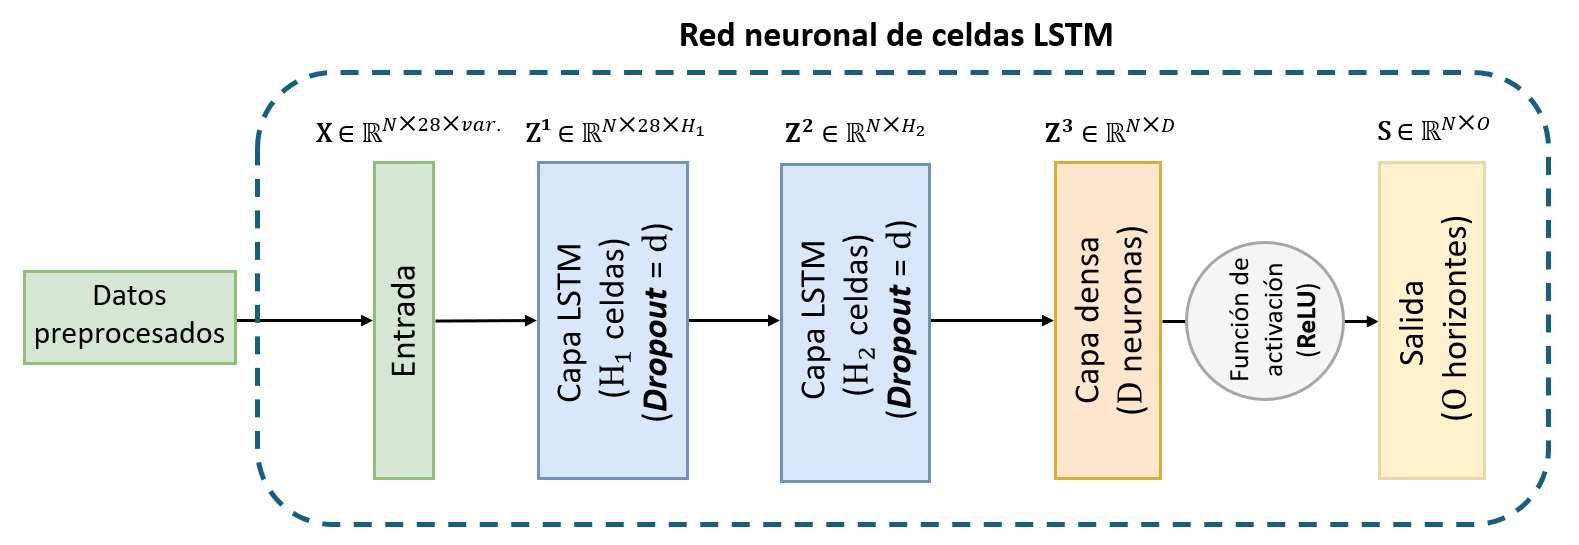

La entrada del modelo está formada por secuencias temporales de longitud 28, correspondientes a los últimos 28 días de información histórica de cada producto, de la misma forma que se hizo en los otros dos modelos del trabajo. Además, en el _input_ también se incluyen las variables explicativas asociadas a cada instante temporal. De este modo, la entrada de la red presenta dimensiones $X \in \mathbb{R}^{N \times 28 \times var.}$, donde $N$ representa el número de muestras y $var.$ el número de variables utilizadas.

La primera capa LSTM recibe estas secuencias completas y devuelve una representación temporal de dimensiones $Z^1 \in \mathbb{R}^{N \times 28 \times H_1}$. En este caso, el hiperparámetro $H_1$ representa el número de celdas de memoria de la capa, y permite controlar la capacidad de la red para capturar patrones temporales complejos en la demanda. Además, como en la definición de la arquitectura se utiliza `return_sequences=True`, se conserva la dimensión temporal de 28 días en el pasado en la salida del bloque. Esto permite que la segunda capa LSTM continúe procesando la dinámica temporal completa.

Posteriormente, la segunda capa LSTM transforma la secuencia anterior en una representación compacta de dimensiones $Z^2 \in \mathbb{R}^{N \times H_2}$, donde $H_2$ también corresponde al número de celdas LSTM de este bloque. En este caso ya no se devuelve la secuencia completa, sino únicamente el último estado oculto de la secuencia, que resume la información temporal más relevante de la ventana de entrada.

También se destaca la inclusión de capas de regularización _dropout_ con probabilidad $d$, cuyo objetivo es reducir el riesgo de sobreajuste mediante la desactivación aleatoria de una fracción de neuronas durante el entrenamiento.

A continuación, la representación temporal obtenida se introduce en una capa totalmente conectada de dimensiones $Z^3 \in \mathbb{R}^{N \times D}$, donde $D$ representa el número de neuronas de la capa densa. Esta capa permite combinar de forma no lineal las características temporales extraídas por las capas LSTM antes de generar la predicción final, por lo que se utiliza una función de activación _ReLU_.

Finalmente, la capa de salida genera un vector $S \in \mathbb{R}^{N \times O}$, donde $O$ representa el número de horizontes temporales predichos simultáneamente. De este modo, la red es capaz de realizar la predicción *multi-step* de la demanda.

En cuanto al proceso de optimización de hiperparámetros, en este caso se ha preferido seguir un método de optimización bayesiana mediante la librería _Optuna_ en lugar de _RandomizedSearchCV_. Esta decisión se debe a que los modelos de redes neuronales presentan un espacio de hiperparámetros muy amplio y complejo, donde las interacciones entre ellos son altamente no lineales. En este contexto, _Optuna_ permite realizar una búsqueda más eficiente al adaptar la exploración del espacio de hiperparámetros en función de los resultados obtenidos en iteraciones anteriores, en lugar de muestrear combinaciones de forma completamente aleatoria. Además, _Optuna_ incorpora mecanismos de _pruning_, que permiten detener de forma anticipada aquellas configuraciones que muestran un rendimiento pobre en etapas tempranas del entrenamiento, reduciendo significativamente el coste computacional.

Dicho esto, varios de los hiperparámetros que se han optimizado están estrechamente relacionados con la propia arquitectura de la red, como $H_1$, $H_2$, $d$ y $D$, aunque también se incluyen otros hiperparámetros como la tasa de aprendizaje y el número de _batches_. A modo de resumen, a continuación se listan todos los hiperparámetros que se han optimizado con _Optuna_ para cada conjunto de datos.

<ul>
    <li>$H_1$ &#8594; Número de celdas de la primera capa LSTM</li>
    <li>$H_2$ &#8594; Número de celdas de la segunda capa LSTM</li>
    <li>$d$ &#8594; Tasa de <i>dropout</i>, es decir, la fracción de celdas que se desactivan en una capa durante el entrenamiento</li>
    <li>$D$ &#8594; Número de neuronas de la capa densa</li>
    <li><i>learning_rate</i> &#8594; Controla el tamaño del paso que el modelo da al actualizar sus pesos internos en respuesta al error estimado</li>
    <li><i>batch_size</i> &#8594; Número de muestras que se procesan en una sola iteración del entrenamiento de la red</li>
</ul>

<ol style="list-style: none; padding-left: 0;">
    <li><a href="#ej1">Modelo global</a></li>
    <li><a href="#ej2">Modelos por <i>cluster</i></a> <br>
        &nbsp;&nbsp;2.1. <a href="#ej2.1"><i>Cluster top_ventas</i></a> <br>
        &nbsp;&nbsp;2.2. <a href="#ej2.2"><i>Cluster residual</i></a> <br>
        &nbsp;&nbsp;2.3. <a href="#ej2.3"><i>Cluster alta_rotacion</i></a> <br>
        &nbsp;&nbsp;2.4. <a href="#ej2.4"><i>Cluster estandar</i></a> <br>
    </li>
</ol>

In [ ]:
import gc

import math
import time
import random
import warnings

import pandas as pd
import numpy as np

import optuna
from optuna.integration import TFKerasPruningCallback

import tensorflow as tf
from tensorflow import keras
from keras.optimizers import Adam
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.metrics import RootMeanSquaredError
from keras.layers import Dense, Input, LSTM, Dropout
from keras.src.losses.losses import mean_squared_error

from sklearn.preprocessing import MinMaxScaler

import matplotlib
import matplotlib.pyplot as plt

from typing import Any, Dict, List

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
%matplotlib inline

<br><br>A continuación se define la función _**secuenciador()**_, que sirve para transformar las series temporales originales en secuencias compatibles con la estructura de entrada requerida por la red neuronal. A diferencia de los modelos basados en árboles de decisión, las redes LSTM no trabajan con observaciones independientes, sino con secuencias ordenadas temporalmente. Por este motivo, los datos deben organizarse en tensores tridimensionales con dimensiones $N \times 28 \times var.$, donde $N$ representa el número de muestras, $28$ se corresponde con la longitud de la secuencia temporal empleada, y $var.$ el número de variables de entrada utilizadas en cada instante temporal.

Para cada producto, la función extrae ventanas temporales de 28 días de longitud que contienen tanto las variables originales del conjunto de datos como un conjunto adicional de atributos derivados calculados a partir de la demanda histórica reciente. De la misma forma que en los otros modelos del trabajo, se calculan estadísticas de ventana móvil como la media, la desviación estándar y el máximo de la demanda para distintos periodos temporales, las cuales posteriormente se replican a lo largo de toda la secuencia para incorporarlas como variables adicionales de entrada.

Asimismo, la función también construye la salida objetivo asociada a cada secuencia, compuesta por los siguientes valores futuros de la demanda. De este modo, cada muestra de entrada contiene un bloque temporal completo de observaciones pasadas, mientras que la salida asociada corresponde a una predicción _multi-step_ de la demanda futura.

Adicionalmente, a diferencia de los secuenciadores utilizados en los modelos _Random Forest_ y _XGBoost_, donde las variables temporales derivadas se incorporaban como columnas independientes de un _DataFrame_ bidimensional, en este caso toda la información temporal se preserva explícitamente dentro de la estructura secuencial de entrada. Esto permite que las capas LSTM aprendan dependencias temporales complejas directamente a partir de la evolución de las variables a lo largo del tiempo.

In [ ]:
# Función para crear las secuencias de un producto
def secuenciador(df: pd.DataFrame, lag: int, horizonte: int, target: str):
    """Para un producto concreto, se extraen los últimos lag valores de las variables explicativas con
    las que se desea crear el modelo
    Argumentos:
        df: pd.DataFrame -> Conjunto de datos que se desea secuenciar
        lag: int -> Número de periodos pasados que se desean emplear
        horizonte: int -> Número de periodos futuros que se desean emplear
        target: str -> Nombre de la variable objetivo

    Devuelve:
        pd.DataFrame -> DataFrame con la serie secuenciada
    """
    x, y = [], []
    ventanas: List [int] = [i for i in range(7, lag + 1, 7)]

    for i in range(len(df) - lag - horizonte + 1):
        subventana_df: pd.DataFrame = df.iloc[i : i + lag]
        serie_target: pd.Series = subventana_df[target]

        atributos = []

        for v in ventanas:
            valores_ventana: pd.Series = serie_target.iloc[-v:]

            atributos.append(valores_ventana.mean())
            atributos.append(valores_ventana.std())
            atributos.append(valores_ventana.max())

        variables_extra: np.ndarray = np.array(atributos, dtype=np.float32)
        variables_extra_repetidas: np.ndarray = np.tile(variables_extra, (lag, 1))

        subventana: np.ndarray = subventana_df.values
        subventana_full: np.ndarray = np.concatenate([subventana, variables_extra_repetidas], axis=1)

        x.append(subventana_full)

        siguientes: np.ndarray = df.iloc[i + lag : i + lag + horizonte][target].values
        y.append(siguientes)

    return x, y

<br><br>
De la misma forma que en los otros modelos del proyecto, también se definen las funciones _**rmse()**_ y _**rmsse_producto()**_, que permiten evaluar el error de las predicciones de los modelos.

La función _**rmse()**_ calcula la raíz del error cuadrático medio entre la demanda real y la demanda predicha sobre el conjunto de prueba. Por otro lado, la función _**rmsse_producto()**_ calcula el error cuadrático medio escalado cada producto y un horizonte temporal concreto, normalizando el error respecto a la variabilidad histórica observada en el conjunto de entrenamiento de cada serie. Este enfoque permite comparar el rendimiento de los modelos entre productos con distintos niveles de demanda.

Para la evaluación de los modelos, ambas métricas se calculan inicialmente para cada combinación de producto, $p$, y horizonte temporal, $h$. Posteriormente, para cada producto se promedian únicamente los errores correspondientes a los horizontes comprendidos dentro del ciclo de aprovisionamiento de cada producto, definido como la suma del tiempo de entrega, $L$, y los días entre pedidos, $R$.

$error_p = \frac{1}{R+L} \sum_{h=1}^{R+L} error_{p,h}$

Finalmente, el rendimiento global de cada modelo se obtiene promediando los errores operativos de todos los productos, $N$.

$error_{modelo} = \frac{1}{N} \sum_{p=1}^{N} error_p$

En el caso del RMSE, esta métrica se utilizará posteriormente en el apartado **Evaluación del Impacto Económico** durante la simulación de inventario para aproximar la incertidumbre asociada a las predicciones y analizar su efecto sobre las decisiones de reposición y los costes operativos del sistema.

In [ ]:
# Funciones para calcular el RMSE y el RMSSE
def rmse(y_real: pd.Series, y_pred: pd.Series) -> float:
    """Devuelve el RMSE de las predicciones de un modelo sobre un conjunto de prueba

    Argumentos:
        y_real: pd.Series -> Demanda real del conjunto de prueba
        y_pred: pd.Series -> Demanda predicha para el conjunto de prueba

    Devuelve
        float -> RMSE
    """
    return np.sqrt(np.mean(np.abs(y_real - y_pred) ** 2))


def rmsse_producto(df: pd.DataFrame, df_test: pd.DataFrame, horizonte: int) -> Dict[str, float]:
    """Devuelve el RMSSE de cada producto para un horizonte temporal concreto

    Argumentos:
        df: pd.DataFrame -> DataFrame completo del conjunto de datos
        df_test: pd.DataFrame -> Resultados del conjunto de prueba
        horizonte: int -> Horizonte temporal

    Devuelve:
        Dict[str, float] -> RMSSE de cada producto en un horizonte temporal concreto
    """
    valores: Dict[str, float] = {}

    for producto, grupo_test in df_test.groupby("producto"):

        y_real: np.ndarray = grupo_test[f"real_{horizonte}"].values
        y_pred: np.ndarray = grupo_test[f"pred_{horizonte}"].values

        numerador: float = np.mean((y_real - y_pred) ** 2)

        # Datos de entrenamiento del producto
        grupo_train: pd.DataFrame = (
            df[df["producto"] == producto]
            .sort_values("fecha")
        )

        PARTICION: int = int(len(grupo_train) * 0.8)

        y_train: np.ndarray = (
            grupo_train[f"hor_{horizonte}"]
            .iloc[:PARTICION]
            .values
        )

        denominador: float = np.mean(
            (y_train[1:] - y_train[:-1]) ** 2
        )

        if denominador != 0 and not np.isnan(denominador):
            valores[producto] = np.sqrt(numerador / denominador)

    return valores

<br><br><a id="ej1"></a>
# 1. Modelo global

En este apartado se preprocesa el conjunto de datos global para la optimización y el entrenamiento de la red neuronal LSTM descrita al comienzo del _notebook_.

In [ ]:
# Se comprueba la disponibilidad de la GPU
print("La GPU", "está disponible" if tf.config.list_physical_devices("GPU") else "no está disponible")

In [ ]:
# Se importan los datos preprocesados del análisis exploratorio de datos
ruta_dataset: str = "dataset_preprocesado.csv"
dataset_global: pd.DataFrame = pd.read_csv(ruta_dataset)
dataset_global.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
# Se selecciona el subconjunto de variables de interés
dataset_global_subset: pd.DataFrame = (
    dataset_global[
        [
            "producto", "fecha", "diasEntrePedidos", "diasLeadtime", "eurPrecioMedio", "bolHoliday_reconstruido", "bolOpen_reconstruido",
            "isPromo", "dia_semana_str_Lunes", "dia_semana_str_Martes", "dia_semana_str_Miércoles", "dia_semana_str_Jueves",
            "dia_semana_str_Viernes", "dia_semana_str_Sábado", "dia_semana_str_Domingo", "udsVenta"
        ] + [f"mes_str_{i}" for i in range(1, 13)]
    ]
)

# Se generan los horizontes futuros necesarios para el cálculo de métricas
HORIZONTE: int = int(max(dataset_global["diasLeadtime"] + dataset_global["diasEntrePedidos"]))

for h in range(1, HORIZONTE + 1):
    dataset_global_subset[f"hor_{h}"] = (
        dataset_global_subset
        .groupby("producto")["udsVenta"]
        .shift(-h)
    )

<br><br>A diferencia de los modelos _Random Forest_ y _XGBoost_, en este modelo se crean las secuencias y los distintos conjuntos necesarios para el entrenamiento y la evaluación de la red neuronal a la vez dentro del mismo bucle, con el objetivo de obtener los tensores de las dimensiones apropiadas.

Para cada producto, la serie temporal se ordena cronológicamente y posteriormente se transforma en secuencias de 28 días de longitud mediante la función _**secuenciador()**_. Una vez generadas las secuencias, se construyen los distintos conjuntos siguiendo el esquema de particiones comentado al inicio del _notebook_. Finalmente, los subconjuntos obtenidos para cada producto se concatenan para construir los tensores globales utilizados durante el entrenamiento de la red LSTM.

In [ ]:
# Se crean los conjuntos de entrenamiento y de prueba del conjunto de datos global
LAG: int = 28
horizontes: List[str] = [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

conjuntos_dataset_global: Dict[str, pd.DataFrame] = {}
lista_x_train, lista_x_val, lista_x_test = [], [], []
lista_y_train, lista_y_val, lista_y_test = [], [], []

for producto, df_producto in dataset_global_subset.drop(columns=horizontes, axis=1).groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values(by="fecha").drop(columns=["producto", "fecha"])

    x_producto, y_producto = secuenciador(df_producto, LAG, HORIZONTE, "udsVenta")

    PARTICION_TRAIN_TEST: int = int(len(x_producto) * 0.8)
    datos_x_train: List[np.ndarray] = x_producto[:PARTICION_TRAIN_TEST]
    lista_x_test.append(np.array(x_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    PARTICION_TRAIN_VAL: int = int(len(datos_x_train) * 0.8)
    lista_x_train.append(np.array(datos_x_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_x_val.append(np.array(datos_x_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

    datos_y_train: List[np.ndarray] = y_producto[:PARTICION_TRAIN_TEST]
    lista_y_test.append(np.array(y_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    lista_y_train.append(np.array(datos_y_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_y_val.append(np.array(datos_y_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

conjuntos_dataset_global["x_train"] = np.concatenate(lista_x_train, axis=0)
conjuntos_dataset_global["x_test"] = np.concatenate(lista_x_test, axis=0)
conjuntos_dataset_global["x_val"] = np.concatenate(lista_x_val, axis=0)

conjuntos_dataset_global["y_train"] = np.concatenate(lista_y_train, axis=0)
conjuntos_dataset_global["y_test"]  = np.concatenate(lista_y_test, axis=0)
conjuntos_dataset_global["y_val"]  = np.concatenate(lista_y_val, axis=0)

# Se eliminan las listas del bucle anterior para liberar memoria
del datos_x_train, datos_y_train
del lista_x_train, lista_x_val, lista_x_test
del lista_y_train, lista_y_val, lista_y_test
gc.collect()

print(f"Las dimensiones del conjunto x_train son {conjuntos_dataset_global["x_train"].shape}")
print(f"Las dimensiones del conjunto y_train son {conjuntos_dataset_global["y_train"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_test son {conjuntos_dataset_global["x_test"].shape}")
print(f"Las dimensiones del conjunto y_test son {conjuntos_dataset_global["y_test"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_val son {conjuntos_dataset_global["x_val"].shape}")
print(f"Las dimensiones del conjunto y_val son {conjuntos_dataset_global["y_val"].shape}")

<br><br>Las variables de entrada y salida se escalan mediante un escalado de tipo _MinMax_, que permite transformar todos los valores al intervalo $[0, 1]$. Este preprocesamiento resulta especialmente importante en redes neuronales, ya que estos modelos son sensibles a la escala de las variables de entrada. Sin este procedimiento, los atributos con magnitudes muy distintas podrían dominar el proceso de aprendizaje y dificultar la convergencia del algoritmo de optimización.

Además, el escalado se realiza una vez generados los conjuntos de entrenamiento, validación y prueba, ajustando los escaladores exclusivamente sobre el conjunto de entrenamiento. Posteriormente, las mismas transformaciones se aplican a los conjuntos de validación y prueba. Este procedimiento resulta imprescindible para evitar fugas de información, ya que utilizar estadísticas calculadas sobre datos futuros durante el escalado introduciría información del conjunto de prueba en el entrenamiento del modelo, produciendo estimaciones condicionadas por un sesgo artificial.

Asimismo, dado que las entradas de la red presentan una estructura tridimensional con dimensiones $N \times 28 \times var.$, los tensores se reorganizan temporalmente en matrices bidimensionales antes de aplicar el escalado, restaurando posteriormente su forma original para alimentar correctamente la arquitectura LSTM.

De forma adicional, algunas de las variables se eliminan para liberar memoria en el _notebook_ y evitar saturar la memoria RAM de este.

In [ ]:
# Se escalan las variables entre 0 y 1
x_train: np.ndarray = conjuntos_dataset_global["x_train"]
x_val: np.ndarray = conjuntos_dataset_global["x_val"]
x_test: np.ndarray = conjuntos_dataset_global["x_test"]

y_train: np.ndarray = conjuntos_dataset_global["y_train"]
y_val: np.ndarray = conjuntos_dataset_global["y_val"]
y_test: np.ndarray = conjuntos_dataset_global["y_test"]

muestras_train, lag, variables = x_train.shape
muestras_val: int  = x_val.shape[0]
muestras_test: int = x_test.shape[0]

x_train_2d: np.ndarray = x_train.reshape(-1, variables)

x_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
x_scaler.fit(x_train_2d)

# Escalado de x_train
x_train_scaled: np.ndarray = x_scaler.transform(x_train_2d).reshape(muestras_train, lag, variables)
del x_train_2d
gc.collect()

# Escalado de x_val
x_val_scaled: np.ndarray = x_scaler.transform(x_val.reshape(-1, variables)).reshape(muestras_val, lag, variables)

# Escalado de x_test
x_test_scaled: np.ndarray = x_scaler.transform(x_test.reshape(-1, variables)).reshape(muestras_test, lag, variables)

conjuntos_dataset_global["x_train"] = x_train_scaled
conjuntos_dataset_global["x_val"] = x_val_scaled
conjuntos_dataset_global["x_test"] = x_test_scaled

# Liberación de memoria
del x_train, x_val, x_test
del x_train_scaled, x_val_scaled, x_test_scaled
gc.collect()

# Escalado de las variables objetivo
y_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
y_train_1d: np.ndarray = y_train.reshape(-1, 1)
y_scaler.fit(y_train_1d)

conjuntos_dataset_global["y_train"] = y_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
conjuntos_dataset_global["y_val"]   = y_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
conjuntos_dataset_global["y_test"]  = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

del y_train, y_val, y_test
gc.collect()

<br><br>Para optimizar los hiperparámetros de la red neuronal con _Optuna_, es necesario definir una función objetivo que se usa para orquestar el entrenamiento de cada experimento de optimización con una combinación de hiperparámetros distinta. Cabe destacar que los experimentos se llevan a cabo empleando el optimizador Adam, y también se configura la opción de _pruning_, que permite aumentar la eficiencia de la búsqueda parando aquellos experimentos que muestran un rendimiento pobre en las primeras épocas de entrenamiento.

In [ ]:
def funcion_objetivo(trial: optuna.trial.Trial, conjuntos: Dict[str, np.ndarray], horizonte: int, semilla: int) -> float:
    """Devuelve el RMSE de un experimento de optimización de hiperparámetros de una red neuronal LSTM

    Argumentos:
        trial (optuna.trial.Trial) -> Iteración del experimento de optimización
        conjuntos (Dict[str, np.ndarray]) -> Diccionario con los conjuntos de entrenamiento y validación
        horizonte (int) -> Número de pasos en el futuro que se desea predecir con el modelo
        semilla (int) -> Semilla para fijar el componente aleatorio de las librerías del notebook con un
        generador aleatorio de números

    Devuelve:
        float -> RMSE promedio de todos los horizontes de la iteración del experimento del modelo
    """
    # Se garantiza la reproducibilidad del proceso de optimización
    tf.random.set_seed(semilla)
    np.random.seed(semilla)
    random.seed(semilla)

    # Hiperparámetros a optimizar
    celdas_lstm_1 = trial.suggest_int("celdas_lstm_1", 32, 128)
    celdas_lstm_2 = trial.suggest_int("celdas_lstm_2", 16, 64)
    neuronas_capa_densa = trial.suggest_int("neuronas_capa_densa", 32, 128)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    tamaño_batch = trial.suggest_categorical("tamaño_batch", [32, 64, 128])
    tasa_aprendizaje = trial.suggest_float("tasa_aprendizaje", 1e-4, 1e-2, log=True)

    # Se crean los conjuntos de tensorflow para los experimentos
    BUFFER_SIZE: int = 1000

    tf_train_opt: tf.data.Dataset = tf.data.Dataset.from_tensor_slices(
        (conjuntos["x_train"], conjuntos["y_train"])
    )
    tf_train_opt: tf.data.Dataset = tf_train_opt.shuffle(BUFFER_SIZE).batch(tamaño_batch).prefetch(tf.data.AUTOTUNE)

    tf_val_opt: tf.data.Dataset = tf.data.Dataset.from_tensor_slices(
        (conjuntos["x_val"], conjuntos["y_val"])
    )
    tf_val_opt: tf.data.Dataset = tf_val_opt.batch(tamaño_batch).prefetch(tf.data.AUTOTUNE)

    # Arquitectura de la red LSTM que se va a optimizar
    lstm_opt: keras.Model = Sequential([

        Input(shape=(LAG, variables)),

        LSTM(celdas_lstm_1, return_sequences=True),
        Dropout(dropout),

        LSTM(celdas_lstm_2),
        Dropout(dropout),

        Dense(neuronas_capa_densa, activation="relu"),
        Dense(horizonte)
    ])

    # Se compila el modelo
    lstm_opt.compile(
        optimizer=Adam(learning_rate=tasa_aprendizaje),
        loss="mean_squared_error",
        metrics=[RootMeanSquaredError(name="rmse")]
    )

    # Se configura una condición de parada de tipo EarlyStopping
    early_stopping: EarlyStopping = EarlyStopping(
      monitor="val_loss",
      patience=3,
      restore_best_weights=True
    )

    # Entrenamiento del modelo
    EPOCHS: int = 10
    history = lstm_opt.fit(
      tf_train_opt,
      validation_data=tf_val_opt,
      epochs=EPOCHS,
      callbacks=[
          early_stopping,
          TFKerasPruningCallback(trial, "val_loss")  # Pruning
      ],
      verbose=1
    )

    # Se evalúa el modelo con el conjunto de validación
    loss, rmse = lstm_opt.evaluate(tf_val_opt, verbose=0)

    # Se libera la memoria entre experimentos
    tf.keras.backend.clear_session()

    return rmse

In [ ]:
# Se inicia un estudio para optimizar los parámetros de la red neuronal
SEMILLA: int = 42
N_TRIALS: int = 50
tiempo_inicial: float = time.time()
print("\nIniciando el estudio de optimización de hiperparámetros\n")

estudio_global = optuna.create_study(
    study_name="Optimización de los hiperparámetros para el dataset global",
    direction="minimize"
)

estudio_global.optimize(
    lambda trial: funcion_objetivo(trial, conjuntos_dataset_global, HORIZONTE, SEMILLA),
    n_trials=N_TRIALS
)

tiempo_final: float = time.time()

print(f"\nLa optimización tardó un total de {round(tiempo_final - tiempo_inicial, 2)} segundos")

print("\nLos mejores hiperparámetros encontrados son:")
for nombre, valor in estudio_global.best_params.items():
    print(f"{nombre}: {valor}")

print(f"\nEl mejor RMSE de validación fue: {estudio_global.best_value}")

In [ ]:
# Se añaden los datos a conjuntos de tensorflow
BATCH: int = estudio_global.best_params["tamaño_batch"]
BUFFER_SIZE: int = 1000

tf_train: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_dataset_global["x_train"], conjuntos_dataset_global["y_train"]))
tf_train: tf.data.Dataset = tf_train.shuffle(BUFFER_SIZE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_val: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_dataset_global["x_val"], conjuntos_dataset_global["y_val"]))
tf_val: tf.data.Dataset = tf_val.batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_test: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_dataset_global["x_test"], conjuntos_dataset_global["y_test"]))
tf_test: tf.data.Dataset = tf_test.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print(f"Conjuntos de datos de tensorflow creados\n")
print(f"Tamaño de batch: {BATCH}")
print(f"Número de batches de entrenamiento: {math.ceil(len(conjuntos_dataset_global["x_train"]) / BATCH)}")
print(f"Número de batches de validación: {math.ceil(len(conjuntos_dataset_global["x_val"]) / BATCH)}")
print(f"Número de batches de prueba: {math.ceil(len(conjuntos_dataset_global["x_test"]) / BATCH)}")

In [ ]:
# Se crea el modelo global de celdas LSTM optimizado y se compila
modelo_global: keras.Model = Sequential([

    Input(shape=(LAG, variables)),

    LSTM(estudio_global.best_params["celdas_lstm_1"], return_sequences=True),
    Dropout(estudio_global.best_params["dropout"]),

    LSTM(estudio_global.best_params["celdas_lstm_2"]),
    Dropout(estudio_global.best_params["dropout"]),

    Dense(estudio_global.best_params["neuronas_capa_densa"], activation="relu"),

    Dense(HORIZONTE)
])

modelo_global.compile(
    optimizer=Adam(learning_rate=estudio_global.best_params["tasa_aprendizaje"]),
    loss="mean_squared_error",
    metrics=[RootMeanSquaredError(name="rmse")]
)

In [ ]:
# Se muestra un resumen de la arquitectura del modelo global
tf.random.set_seed(SEMILLA)

modelo_global.summary()
print(f"El modelo contiene un total de {modelo_global.count_params()} parámetros")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_global.trainable_weights])} parámetros entrenables")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_global.non_trainable_weights])} parámetros no entrenables")

In [ ]:
# Se entrena el modelo global LSTM
EPOCHS: int = 50
PATIENCE: int = 5

early_stopping: EarlyStopping = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True
)

tiempo_inicial: float = time.time()

history_global = modelo_global.fit(
  tf_train,
  epochs=EPOCHS,
  validation_data=tf_val,
  callbacks=[early_stopping],
  verbose=1
)

tiempo_final: float = time.time()
print(f"El modelo global tardó {round(tiempo_final - tiempo_inicial, 2)} segundos en entrenarse")

In [ ]:
# Se realizan las predicciones en el conjunto de prueba
y_pred_global_inv: np.ndarray = modelo_global.predict(tf_test)
y_pred_global = y_scaler.inverse_transform(y_pred_global_inv.reshape(-1, 1)).reshape(y_pred_global_inv.shape)

y_pred_global_df: pd.DataFrame = pd.DataFrame(
    y_pred_global,
    columns=[f"pred_{h}" for h in range(1, HORIZONTE + 1)]
)

In [ ]:
# Se asocian a las predicciones y los valores reales los productos y las fechas correspondientes
lista_meta_test: List[pd.DataFrame] = []

for producto, df_producto in dataset_global_subset.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    N_SEC: int = len(df_producto) - LAG - HORIZONTE + 1
    PARTICION_SEC: int = int(N_SEC * 0.8)

    meta_info_test = df_producto.iloc[LAG + PARTICION_SEC : LAG + N_SEC][[
        "producto", "fecha", "udsVenta", "diasLeadtime", "diasEntrePedidos", "eurPrecioMedio"
    ]]
    lista_meta_test.append(meta_info_test)

meta_test: pd.DataFrame = pd.concat(lista_meta_test, ignore_index=True)

y_test_escalado: np.ndarray = conjuntos_dataset_global["y_test"]

y_real_global_df: pd.DataFrame = pd.DataFrame(
    y_scaler.inverse_transform(
        conjuntos_dataset_global["y_test"].reshape(-1, 1)
    ).reshape(y_test_escalado.shape),
    columns=[f"real_{h}" for h in range(1, HORIZONTE + 1)]
)

resultados_modelo_global: pd.DataFrame = pd.concat(
    [meta_test.reset_index(drop=True), y_real_global_df, y_pred_global_df],
    axis=1
)

resultados_modelo_global["fecha"] = pd.to_datetime(resultados_modelo_global["fecha"])

In [ ]:
# Se calculan los promedios de los errores cometidos en el conjunto de prueba del dataset global
rmses: Dict[str, float] = {
    i: rmse(
        resultados_modelo_global[f"real_{i}"],
        resultados_modelo_global[f"pred_{i}"]
    ) for i in range(1, HORIZONTE + 1)
}

In [ ]:
# Se visualiza la evolución del promedio del RMSE de todos los productos en los horizontes temporales
plt.plot(range(1, HORIZONTE + 1, 1), rmses.values(), color="blue")

plt.title("Promedio del RMSE de los horizontes temporales del modelo global")
plt.xlabel("Días futuros")
plt.xticks(range(1, HORIZONTE + 1, 5))
plt.ylabel("RMSE promedio por producto")

plt.grid(True, alpha=0.3)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

<br><br> Se calculan los RMSE y RMSSE a nivel de horizonte por producto del modelo global. Los RMSE se exportan en un archivo _csv_ para la **Evaluación del Impacto Económico**, y los RMSSE se usan para obtener el promedio del modelo de esta métrica como se explicó al inicio del _notebook_.

In [ ]:
# Se calculan los RMSE en el conjunto de prueba del dataset global por producto y se exportan para la evaluación económica
rmses_global: List[pd.DataFrame] = []

for producto, df_producto in resultados_modelo_global.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    rmses_producto: Dict[str, float] = {
        f"hor_{i}": [rmse(
            df_producto[f"real_{i}"],
            df_producto[f"pred_{i}"]
        )] for i in range(1, HORIZONTE + 1)
    }

    rmses_df: pd.DataFrame = pd.DataFrame(rmses_producto)
    rmses_df["producto"] = producto
    rmses_global.append(rmses_df)

rmses_global: pd.DataFrame = pd.concat(rmses_global, ignore_index=True)
rmses_global.to_csv("rmses_lstm_global.csv")

In [ ]:
# Se calculan los RMSSE de cada producto en cada horizonte temporal del modelo global
lista_rmsse: List[Dict[str, Any]] = []
for horizonte in range(1, HORIZONTE + 1):

    rmsse_horizonte: Dict[str, float] = rmsse_producto(
        dataset_global_subset,
        resultados_modelo_global,
        horizonte
    )

    for producto, valor in rmsse_horizonte.items():

        lista_rmsse.append({
            "producto": producto,
            "horizonte": horizonte,
            "rmsse": valor
        })

# Se disponen todas las combinaciones de RMSSE de productos y horizontes en un DataFrame
df_rmsses: pd.DataFrame = pd.DataFrame(lista_rmsse)
df_rmsses = df_rmsses.pivot(
    index="producto",
    columns="horizonte",
    values="rmsse"
).reset_index()
df_rmsses.columns = ["producto"] + [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

# Se calcula el RMSSE de cada producto como el promedio de todos los RMSSE en cada horizonte temporal
# hasta el que corresponde con el ciclo de aprovisionamiento del artículo
rmsse_productos: List[float] = []
for producto, df_producto in resultados_modelo_global.groupby("producto"):

    ciclo_aprov: int = int(
        df_producto["diasLeadtime"].mean() +
        df_producto["diasEntrePedidos"].mean()
    )

    columnas_horizontes: List[str] = [f"hor_{h}" for h in range(1, ciclo_aprov + 1)]

    fila_producto_df = df_rmsses[df_rmsses["producto"] == producto]
    if fila_producto_df.empty:
        continue
    fila_producto: pd.Series = fila_producto_df.iloc[0]

    rmsse_producto_promedio: float = fila_producto[columnas_horizontes].mean()
    rmsse_productos.append(rmsse_producto_promedio)

# Se promedian todos los RMSSEs de los ítems para obtener el RMSSE del modelo global
rmsse_modelo_global: float = np.mean(rmsse_productos)
print(f"El RMSSE promedio del modelo global es {rmsse_modelo_global:.4f}")

In [ ]:
# Se visualiza la demanda real frente a las predicciones de tres productos aleatorios del dataset global
N_PRODUCTOS: int = 3
N_PREDICCIONES: int = 3
seleccion_productos: List[int] = random.sample(resultados_modelo_global["producto"].unique().tolist(), N_PRODUCTOS)

fig, axs = plt.subplots(nrows=len(seleccion_productos), ncols=1, figsize=(10, 20))

for ax, producto in zip(axs, seleccion_productos):
    res_producto: pd.DataFrame = resultados_modelo_global[resultados_modelo_global["producto"] == producto]
    seleccion_predicciones: List[int] = random.sample(range(len(res_producto)), N_PREDICCIONES)

    fecha_max: str = res_producto["fecha"].max()
    indices_validos: List[int] = [
        i for i in range(len(res_producto))
        if res_producto.iloc[i]["fecha"] + pd.Timedelta(days=HORIZONTE) <= fecha_max
    ]
    seleccion_predicciones: List[int] = random.sample(indices_validos, N_PREDICCIONES)

    fechas_real: pd.Series = res_producto["fecha"] + pd.Timedelta(days=1)
    ax.plot(fechas_real, res_producto["real_1"], label="demanda_real", color="blue", alpha=0.5)

    for i, indice_prediccion in enumerate(seleccion_predicciones):
        fila: pd.Series = res_producto.iloc[indice_prediccion]
        predicciones = [fila[f"pred_{h}"] for h in range(1, HORIZONTE + 1)]

        fecha_inicio: str = fila["fecha"]
        fechas_prediccion = [fecha_inicio + pd.Timedelta(days=h) for h in range(1, HORIZONTE + 1)]

        ax.plot(fechas_prediccion, predicciones, label=f"prediccion_{i + 1}", linestyle="--", alpha=0.5)

    ax.set_title(f"Demanda real Vs Predicciones de la demanda del producto {producto} del dataset global")
    ax.set_xlabel("Días")
    ax.set_xticks([res_producto["fecha"].iloc[i] for i in range(0, len(res_producto["fecha"]), 20)])
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Unidades")

    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
# Se exportan los resultados
resultados_modelo_global.to_csv("res_lstm_global.csv")

<br><br><a id="ej2"></a>
# 2. Modelos por _cluster_

En este apartado se incluyen los flujos de trabajo para entrenar las redes LSTM con los datos de los distintos _clusters_ que se identificaron durante el **Análisis Exploratorio de los Datos**.

<a id="ej2.1"></a>
## 2.1. _Cluster top_ventas_

El flujo de trabajo para el entrenamiento de la red LSTM a partir de los datos de este _cluster_ es el mismo que se ha seguido para el conjunto de datos global.

In [ ]:
# Se comprueba la disponibilidad de la GPU
print("La GPU", "está disponible" if tf.config.list_physical_devices("GPU") else "no está disponible")

In [ ]:
# Se extrae el grupo top_ventas del dataset global
top_ventas: pd.DataFrame = dataset_global[dataset_global["cluster_nombre"] == "top_ventas"]

In [ ]:
# Se selecciona el subconjunto de variables de interés
top_ventas_subset: pd.DataFrame = (
    top_ventas[
        [
            "producto", "fecha", "diasEntrePedidos", "diasLeadtime", "eurPrecioMedio", "bolHoliday_reconstruido", "bolOpen_reconstruido",
            "isPromo", "dia_semana_str_Lunes", "dia_semana_str_Martes", "dia_semana_str_Miércoles", "dia_semana_str_Jueves",
            "dia_semana_str_Viernes", "dia_semana_str_Sábado", "dia_semana_str_Domingo", "udsVenta"
        ] + [f"mes_str_{i}" for i in range(1, 13)]
    ]
)

# Se generan los horizontes futuros necesarios para el cálculo de métricas
HORIZONTE: int = int(max(top_ventas["diasLeadtime"] + top_ventas["diasEntrePedidos"]))

for h in range(1, HORIZONTE + 1):
    top_ventas_subset[f"hor_{h}"] = (
        top_ventas_subset
        .groupby("producto")["udsVenta"]
        .shift(-h)
    )

In [ ]:
# Se crean los conjuntos de entrenamiento y de prueba del conjunto de datos del cluster top_ventas
horizontes: List[str] = [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

conjuntos_top_ventas: Dict[str, pd.DataFrame] = {}
lista_x_train, lista_x_val, lista_x_test = [], [], []
lista_y_train, lista_y_val, lista_y_test = [], [], []

for producto, df_producto in top_ventas_subset.drop(columns=horizontes, axis=1).groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values(by="fecha").drop(columns=["producto", "fecha"])

    x_producto, y_producto = secuenciador(df_producto, LAG, HORIZONTE, "udsVenta")

    PARTICION_TRAIN_TEST: int = int(len(x_producto) * 0.8)
    datos_x_train: List[np.ndarray] = x_producto[:PARTICION_TRAIN_TEST]
    lista_x_test.append(np.array(x_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    PARTICION_TRAIN_VAL: int = int(len(datos_x_train) * 0.8)
    lista_x_train.append(np.array(datos_x_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_x_val.append(np.array(datos_x_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

    datos_y_train: List[np.ndarray] = y_producto[:PARTICION_TRAIN_TEST]
    lista_y_test.append(np.array(y_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    lista_y_train.append(np.array(datos_y_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_y_val.append(np.array(datos_y_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

conjuntos_top_ventas["x_train"] = np.concatenate(lista_x_train, axis=0)
conjuntos_top_ventas["x_test"] = np.concatenate(lista_x_test, axis=0)
conjuntos_top_ventas["x_val"] = np.concatenate(lista_x_val, axis=0)

conjuntos_top_ventas["y_train"] = np.concatenate(lista_y_train, axis=0)
conjuntos_top_ventas["y_test"]  = np.concatenate(lista_y_test, axis=0)
conjuntos_top_ventas["y_val"]  = np.concatenate(lista_y_val, axis=0)

# Se eliminan las listas del bucle anterior para liberar memoria
del datos_x_train, datos_y_train
del lista_x_train, lista_x_val, lista_x_test
del lista_y_train, lista_y_val, lista_y_test
gc.collect()

print(f"Las dimensiones del conjunto x_train son {conjuntos_top_ventas["x_train"].shape}")
print(f"Las dimensiones del conjunto y_train son {conjuntos_top_ventas["y_train"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_test son {conjuntos_top_ventas["x_test"].shape}")
print(f"Las dimensiones del conjunto y_test son {conjuntos_top_ventas["y_test"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_val son {conjuntos_top_ventas["x_val"].shape}")
print(f"Las dimensiones del conjunto y_val son {conjuntos_top_ventas["y_val"].shape}")

In [ ]:
# Se escalan las variables entre 0 y 1
x_train: np.ndarray = conjuntos_top_ventas["x_train"]
x_val: np.ndarray = conjuntos_top_ventas["x_val"]
x_test: np.ndarray = conjuntos_top_ventas["x_test"]

y_train: np.ndarray = conjuntos_top_ventas["y_train"]
y_val: np.ndarray = conjuntos_top_ventas["y_val"]
y_test: np.ndarray = conjuntos_top_ventas["y_test"]

muestras_train, lag, variables = x_train.shape
muestras_val: int  = x_val.shape[0]
muestras_test: int = x_test.shape[0]

x_train_2d: np.ndarray = x_train.reshape(-1, variables)

x_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
x_scaler.fit(x_train_2d)

# Escalado de x_train
x_train_scaled: np.ndarray = x_scaler.transform(x_train_2d).reshape(muestras_train, lag, variables)
del x_train_2d
gc.collect()

# Escalado de x_val
x_val_scaled: np.ndarray = x_scaler.transform(x_val.reshape(-1, variables)).reshape(muestras_val, lag, variables)

# Escalado de x_test
x_test_scaled: np.ndarray = x_scaler.transform(x_test.reshape(-1, variables)).reshape(muestras_test, lag, variables)

conjuntos_top_ventas["x_train"] = x_train_scaled
conjuntos_top_ventas["x_val"] = x_val_scaled
conjuntos_top_ventas["x_test"] = x_test_scaled

# Liberación de memoria
del x_train, x_val, x_test
del x_train_scaled, x_val_scaled, x_test_scaled
gc.collect()

# Escalado de las variables objetivo
y_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
y_train_1d: np.ndarray = y_train.reshape(-1, 1)
y_scaler.fit(y_train_1d)

conjuntos_top_ventas["y_train"] = y_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
conjuntos_top_ventas["y_val"]   = y_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
conjuntos_top_ventas["y_test"]  = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

del y_train, y_val, y_test
gc.collect()

In [ ]:
# Se inicia un estudio para optimizar los parámetros de la red neuronal
tiempo_inicial: float = time.time()
print("\nIniciando el estudio de optimización de hiperparámetros de top_ventas\n")

estudio_top_ventas = optuna.create_study(
    study_name="Optimización de los hiperparámetros para el cluster top_ventas",
    direction="minimize"
)

estudio_top_ventas.optimize(
    lambda trial: funcion_objetivo(trial, conjuntos_top_ventas, HORIZONTE, SEMILLA),
    n_trials=N_TRIALS
)

tiempo_final: float = time.time()

print(f"\nLa optimización tardó un total de {round(tiempo_final - tiempo_inicial, 2)} segundos")

print("\nLos mejores hiperparámetros encontrados son:")
for nombre, valor in estudio_top_ventas.best_params.items():
    print(f"{nombre}: {valor}")

print(f"\nEl mejor RMSE de validación fue: {estudio_top_ventas.best_value}")

In [ ]:
# Se añaden los datos a conjuntos de tensorflow
BATCH: int = estudio_top_ventas.best_params["tamaño_batch"]
BUFFER_SIZE: int = 1000

tf_train: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_top_ventas["x_train"], conjuntos_top_ventas["y_train"]))
tf_train: tf.data.Dataset = tf_train.shuffle(BUFFER_SIZE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_val: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_top_ventas["x_val"], conjuntos_top_ventas["y_val"]))
tf_val: tf.data.Dataset = tf_val.batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_test: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_top_ventas["x_test"], conjuntos_top_ventas["y_test"]))
tf_test: tf.data.Dataset = tf_test.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print(f"Conjuntos de datos de tensorflow creados\n")
print(f"Tamaño de batch: {BATCH}")
print(f"Número de batches de entrenamiento: {math.ceil(len(conjuntos_top_ventas["x_train"]) / BATCH)}")
print(f"Número de batches de validación: {math.ceil(len(conjuntos_top_ventas["x_val"]) / BATCH)}")
print(f"Número de batches de prueba: {math.ceil(len(conjuntos_top_ventas["x_test"]) / BATCH)}")

In [ ]:
# Se crea el modelo del cluster top_ventas de celdas LSTM optimizado y se compila
modelo_top_ventas: keras.Model = Sequential([

    Input(shape=(LAG, variables)),

    LSTM(estudio_top_ventas.best_params["celdas_lstm_1"], return_sequences=True),
    Dropout(estudio_top_ventas.best_params["dropout"]),

    LSTM(estudio_top_ventas.best_params["celdas_lstm_2"]),
    Dropout(estudio_top_ventas.best_params["dropout"]),

    Dense(estudio_top_ventas.best_params["neuronas_capa_densa"], activation="relu"),

    Dense(HORIZONTE)
])

modelo_top_ventas.compile(
    optimizer=Adam(learning_rate=estudio_top_ventas.best_params["tasa_aprendizaje"]),
    loss="mean_squared_error",
    metrics=[RootMeanSquaredError(name="rmse")]
)

In [ ]:
# Se muestra un resumen de la arquitectura del modelo del cluster top_ventas
tf.random.set_seed(SEMILLA)

modelo_top_ventas.summary()
print(f"El modelo contiene un total de {modelo_top_ventas.count_params()} parámetros")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_top_ventas.trainable_weights])} parámetros entrenables")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_top_ventas.non_trainable_weights])} parámetros no entrenables")

In [ ]:
# Se entrena el modelo LSTM para los datos del cluster top_ventas
tiempo_inicial: float = time.time()

history_top_ventas = modelo_top_ventas.fit(
  tf_train,
  epochs=EPOCHS,
  validation_data=tf_val,
  callbacks=[early_stopping],
  verbose=1
)

tiempo_final: float = time.time()
print(f"El modelo de top_ventas tardó {round(tiempo_final - tiempo_inicial, 2)} segundos en entrenarse")

In [ ]:
# Se realizan las predicciones en el conjunto de prueba
y_pred_top_ventas_inv: np.ndarray = modelo_top_ventas.predict(tf_test)
y_pred_top_ventas = y_scaler.inverse_transform(y_pred_top_ventas_inv.reshape(-1, 1)).reshape(y_pred_top_ventas_inv.shape)

y_pred_top_ventas_df: pd.DataFrame = pd.DataFrame(
    y_pred_top_ventas,
    columns=[f"pred_{h}" for h in range(1, HORIZONTE + 1)]
)

In [ ]:
# Se asocian a las predicciones y los valores reales los productos y las fechas correspondientes
lista_meta_test: List[pd.DataFrame] = []

for producto, df_producto in top_ventas_subset.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    N_SEC: int = len(df_producto) - LAG - HORIZONTE + 1
    PARTICION_SEC: int = int(N_SEC * 0.8)

    meta_info_test = df_producto.iloc[LAG + PARTICION_SEC : LAG + N_SEC][[
        "producto", "fecha", "udsVenta", "diasLeadtime", "diasEntrePedidos", "eurPrecioMedio"
    ]]
    lista_meta_test.append(meta_info_test)

meta_test: pd.DataFrame = pd.concat(lista_meta_test, ignore_index=True)

y_test_escalado: np.ndarray = conjuntos_top_ventas["y_test"]

y_real_top_ventas_df: pd.DataFrame = pd.DataFrame(
    y_scaler.inverse_transform(
        conjuntos_top_ventas["y_test"].reshape(-1, 1)
    ).reshape(y_test_escalado.shape),
    columns=[f"real_{h}" for h in range(1, HORIZONTE + 1)]
)

resultados_top_ventas: pd.DataFrame = pd.concat(
    [meta_test.reset_index(drop=True), y_real_top_ventas_df, y_pred_top_ventas_df],
    axis=1
)

resultados_top_ventas["fecha"] = pd.to_datetime(resultados_top_ventas["fecha"])

In [ ]:
# Se calculan los promedios de los errores cometidos en el conjunto de prueba del dataset top_ventas
rmses: Dict[str, float] = {
    i: rmse(
        resultados_top_ventas[f"real_{i}"],
        resultados_top_ventas[f"pred_{i}"]
    ) for i in range(1, HORIZONTE + 1)
}

In [ ]:
# Se visualiza la evolución del promedio del RMSE de todos los productos en los horizontes temporales
plt.plot(range(1, HORIZONTE + 1, 1), rmses.values(), color="blue")

plt.title("Promedio del RMSE de los horizontes temporales del modelo top_ventas")
plt.xlabel("Días futuros")
plt.xticks(range(1, HORIZONTE + 1, 5))
plt.ylabel("RMSE promedio por producto")

plt.grid(True, alpha=0.3)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

<br><br>Se calculan los RMSE y RMSSE a nivel de horizonte por producto del _cluster top_ventas_. Los RMSE se exportan en un archivo _csv_ para la **Evaluación del Impacto Económico**, y los RMSSE se usan para obtener el promedio del modelo de esta métrica como se explicó al inicio del _notebook_.

In [ ]:
# Se calculan los RMSE en el conjunto de prueba de top_ventas por producto y se exportan para la evaluación económica
rmses_top_ventas: List[pd.DataFrame] = []

for producto, df_producto in resultados_top_ventas.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    rmses_producto: Dict[str, float] = {
        f"hor_{i}": [rmse(
            df_producto[f"real_{i}"],
            df_producto[f"pred_{i}"]
        )] for i in range(1, HORIZONTE + 1)
    }

    rmses_df: pd.DataFrame = pd.DataFrame(rmses_producto)
    rmses_df["producto"] = producto
    rmses_top_ventas.append(rmses_df)

rmses_top_ventas: pd.DataFrame = pd.concat(rmses_top_ventas, ignore_index=True)
rmses_top_ventas.to_csv("rmses_lstm_top_ventas.csv")

In [ ]:
# Se calculan los RMSSE de cada producto en cada horizonte temporal del modelo top_ventas
lista_rmsse: List[Dict[str, Any]] = []
for horizonte in range(1, HORIZONTE + 1):

    rmsse_horizonte: Dict[str, float] = rmsse_producto(
        top_ventas_subset,
        resultados_top_ventas,
        horizonte
    )

    for producto, valor in rmsse_horizonte.items():

        lista_rmsse.append({
            "producto": producto,
            "horizonte": horizonte,
            "rmsse": valor
        })

# Se disponen todas las combinaciones de RMSSE de productos y horizontes en un DataFrame
df_rmsses: pd.DataFrame = pd.DataFrame(lista_rmsse)
df_rmsses = df_rmsses.pivot(
    index="producto",
    columns="horizonte",
    values="rmsse"
).reset_index()
df_rmsses.columns = ["producto"] + [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

# Se calcula el RMSSE de cada producto como el promedio de todos los RMSSE en cada horizonte temporal
# hasta el que corresponde con el ciclo de aprovisionamiento del artículo
rmsse_productos: List[float] = []
for producto, df_producto in resultados_top_ventas.groupby("producto"):

    ciclo_aprov: int = int(
        df_producto["diasLeadtime"].mean() +
        df_producto["diasEntrePedidos"].mean()
    )

    columnas_horizontes: List[str] = [f"hor_{h}" for h in range(1, ciclo_aprov + 1)]

    fila_producto_df = df_rmsses[df_rmsses["producto"] == producto]
    if fila_producto_df.empty:
        continue
    fila_producto: pd.Series = fila_producto_df.iloc[0]

    rmsse_producto_promedio: float = fila_producto[columnas_horizontes].mean()
    rmsse_productos.append(rmsse_producto_promedio)

# Se promedian todos los RMSSEs de los ítems para obtener el RMSSE del modelo top_ventas
rmsse_modelo_top_ventas: float = np.mean(rmsse_productos)
print(f"El RMSSE promedio del modelo top_ventas es {rmsse_modelo_top_ventas:.4f}")

In [ ]:
N_PRODUCTOS: int = 3
N_PREDICCIONES: int = 3
# Se visualiza la demanda real frente a las predicciones de tres productos aleatorios de top_ventas
seleccion_productos: List[int] = random.sample(resultados_top_ventas["producto"].unique().tolist(), N_PRODUCTOS)

fig, axs = plt.subplots(nrows=len(seleccion_productos), ncols=1, figsize=(10, 20))

for ax, producto in zip(axs, seleccion_productos):
    res_producto: pd.DataFrame = resultados_top_ventas[resultados_top_ventas["producto"] == producto]
    seleccion_predicciones: List[int] = random.sample(range(len(res_producto)), N_PREDICCIONES)

    fecha_max: str = res_producto["fecha"].max()
    indices_validos: List[int] = [
        i for i in range(len(res_producto))
        if res_producto.iloc[i]["fecha"] + pd.Timedelta(days=HORIZONTE) <= fecha_max
    ]
    seleccion_predicciones: List[int] = random.sample(indices_validos, N_PREDICCIONES)

    fechas_real: pd.Series = res_producto["fecha"] + pd.Timedelta(days=1)
    ax.plot(fechas_real, res_producto["real_1"], label="demanda_real", color="blue", alpha=0.5)

    for i, indice_prediccion in enumerate(seleccion_predicciones):
        fila: pd.Series = res_producto.iloc[indice_prediccion]
        predicciones = [fila[f"pred_{h}"] for h in range(1, HORIZONTE + 1)]

        fecha_inicio: str = fila["fecha"]
        fechas_prediccion = [fecha_inicio + pd.Timedelta(days=h) for h in range(1, HORIZONTE + 1)]

        ax.plot(fechas_prediccion, predicciones, label=f"prediccion_{i + 1}", linestyle="--", alpha=0.5)

    ax.set_title(f"Demanda real Vs Predicciones de la demanda del producto {producto} de top_ventas")
    ax.set_xlabel("Días")
    ax.set_xticks([res_producto["fecha"].iloc[i] for i in range(0, len(res_producto["fecha"]), 20)])
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Unidades")

    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
# Se exportan los resultados
resultados_top_ventas.to_csv("res_lstm_top_ventas.csv")

<a id="ej2.2"></a>
## 2.2. _Cluster residual_

Siguiendo el mismo flujo de trabajo definido para cada conjunto, se procede con el preprocesamiento de los datos del _cluster residual_, así como la optimización y el entrenamiento del modelo LSTM correspondiente.

In [ ]:
# Se comprueba la disponibilidad de la GPU
print("La GPU", "está disponible" if tf.config.list_physical_devices("GPU") else "no está disponible")

In [ ]:
# Se extrae el grupo residual del dataset global
residual: pd.DataFrame = dataset_global[dataset_global["cluster_nombre"] == "residual"]

In [ ]:
# Se selecciona el subconjunto de variables de interés
residual_subset: pd.DataFrame = (
    residual[
        [
            "producto", "fecha", "diasEntrePedidos", "diasLeadtime", "eurPrecioMedio", "bolHoliday_reconstruido", "bolOpen_reconstruido",
            "isPromo", "dia_semana_str_Lunes", "dia_semana_str_Martes", "dia_semana_str_Miércoles", "dia_semana_str_Jueves",
            "dia_semana_str_Viernes", "dia_semana_str_Sábado", "dia_semana_str_Domingo", "udsVenta"
        ] + [f"mes_str_{i}" for i in range(1, 13)]
    ]
)

# Se generan los horizontes futuros necesarios para el cálculo de métricas
HORIZONTE: int = int(max(residual["diasLeadtime"] + residual["diasEntrePedidos"]))

for h in range(1, HORIZONTE + 1):
    residual_subset[f"hor_{h}"] = (
        residual_subset
        .groupby("producto")["udsVenta"]
        .shift(-h)
    )

In [ ]:
# Se crean los conjuntos de entrenamiento y de prueba del conjunto de datos del cluster residual
HORIZONTE: int = int(max(residual["diasLeadtime"] + residual["diasEntrePedidos"]))
horizontes: List[str] = [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

conjuntos_residual: Dict[str, pd.DataFrame] = {}
lista_x_train, lista_x_val, lista_x_test = [], [], []
lista_y_train, lista_y_val, lista_y_test = [], [], []

for producto, df_producto in residual_subset.drop(columns=horizontes, axis=1).groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values(by="fecha").drop(columns=["producto", "fecha"])

    x_producto, y_producto = secuenciador(df_producto, LAG, HORIZONTE, "udsVenta")

    PARTICION_TRAIN_TEST: int = int(len(x_producto) * 0.8)
    datos_x_train: List[np.ndarray] = x_producto[:PARTICION_TRAIN_TEST]
    lista_x_test.append(np.array(x_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    PARTICION_TRAIN_VAL: int = int(len(datos_x_train) * 0.8)
    lista_x_train.append(np.array(datos_x_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_x_val.append(np.array(datos_x_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

    datos_y_train: List[np.ndarray] = y_producto[:PARTICION_TRAIN_TEST]
    lista_y_test.append(np.array(y_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    lista_y_train.append(np.array(datos_y_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_y_val.append(np.array(datos_y_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

conjuntos_residual["x_train"] = np.concatenate(lista_x_train, axis=0)
conjuntos_residual["x_test"] = np.concatenate(lista_x_test, axis=0)
conjuntos_residual["x_val"] = np.concatenate(lista_x_val, axis=0)

conjuntos_residual["y_train"] = np.concatenate(lista_y_train, axis=0)
conjuntos_residual["y_test"]  = np.concatenate(lista_y_test, axis=0)
conjuntos_residual["y_val"]  = np.concatenate(lista_y_val, axis=0)

# Se eliminan las listas del bucle anterior para liberar memoria
del datos_x_train, datos_y_train
del lista_x_train, lista_x_val, lista_x_test
del lista_y_train, lista_y_val, lista_y_test
gc.collect()

print(f"Las dimensiones del conjunto x_train son {conjuntos_residual["x_train"].shape}")
print(f"Las dimensiones del conjunto y_train son {conjuntos_residual["y_train"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_test son {conjuntos_residual["x_test"].shape}")
print(f"Las dimensiones del conjunto y_test son {conjuntos_residual["y_test"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_val son {conjuntos_residual["x_val"].shape}")
print(f"Las dimensiones del conjunto y_val son {conjuntos_residual["y_val"].shape}")

In [ ]:
# Se escalan las variables entre 0 y 1
x_train: np.ndarray = conjuntos_residual["x_train"]
x_val: np.ndarray = conjuntos_residual["x_val"]
x_test: np.ndarray = conjuntos_residual["x_test"]

y_train: np.ndarray = conjuntos_residual["y_train"]
y_val: np.ndarray = conjuntos_residual["y_val"]
y_test: np.ndarray = conjuntos_residual["y_test"]

muestras_train, lag, variables = x_train.shape
muestras_val: int  = x_val.shape[0]
muestras_test: int = x_test.shape[0]

x_train_2d: np.ndarray = x_train.reshape(-1, variables)

x_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
x_scaler.fit(x_train_2d)

# Escalado de x_train
x_train_scaled: np.ndarray = x_scaler.transform(x_train_2d).reshape(muestras_train, lag, variables)
del x_train_2d
gc.collect()

# Escalado de x_val
x_val_scaled: np.ndarray = x_scaler.transform(x_val.reshape(-1, variables)).reshape(muestras_val, lag, variables)

# Escalado de x_test
x_test_scaled: np.ndarray = x_scaler.transform(x_test.reshape(-1, variables)).reshape(muestras_test, lag, variables)

conjuntos_residual["x_train"] = x_train_scaled
conjuntos_residual["x_val"] = x_val_scaled
conjuntos_residual["x_test"] = x_test_scaled

# Liberación de memoria
del x_train, x_val, x_test
del x_train_scaled, x_val_scaled, x_test_scaled
gc.collect()

# Escalado de las variables objetivo
y_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
y_train_1d: np.ndarray = y_train.reshape(-1, 1)
y_scaler.fit(y_train_1d)

conjuntos_residual["y_train"] = y_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
conjuntos_residual["y_val"]   = y_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
conjuntos_residual["y_test"]  = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

del y_train, y_val, y_test
gc.collect()

In [ ]:
# Se inicia un estudio para optimizar los parámetros de la red neuronal
tiempo_inicial: float = time.time()
print("\nIniciando el estudio de optimización de hiperparámetros del cluster residual\n")

estudio_residual = optuna.create_study(
    study_name="Optimización de los hiperparámetros para el cluster residual",
    direction="minimize"
)

estudio_residual.optimize(
    lambda trial: funcion_objetivo(trial, conjuntos_residual, HORIZONTE, SEMILLA),
    n_trials=N_TRIALS
)

tiempo_final: float = time.time()

print(f"\nLa optimización tardó un total de {round(tiempo_final - tiempo_inicial, 2)} segundos")

print("\nLos mejores hiperparámetros encontrados son:")
for nombre, valor in estudio_residual.best_params.items():
    print(f"{nombre}: {valor}")

print(f"\nEl mejor RMSE de validación fue: {estudio_residual.best_value}")

In [ ]:
# Se añaden los datos a conjuntos de tensorflow
BATCH: int = estudio_residual.best_params["tamaño_batch"]
BUFFER_SIZE: int = 1000

tf_train: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_residual["x_train"], conjuntos_residual["y_train"]))
tf_train: tf.data.Dataset = tf_train.shuffle(BUFFER_SIZE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_val: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_residual["x_val"], conjuntos_residual["y_val"]))
tf_val: tf.data.Dataset = tf_val.batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_test: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_residual["x_test"], conjuntos_residual["y_test"]))
tf_test: tf.data.Dataset = tf_test.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print(f"Conjuntos de datos de tensorflow creados\n")
print(f"Tamaño de batch: {BATCH}")
print(f"Número de batches de entrenamiento: {math.ceil(len(conjuntos_residual["x_train"]) / BATCH)}")
print(f"Número de batches de validación: {math.ceil(len(conjuntos_residual["x_val"]) / BATCH)}")
print(f"Número de batches de prueba: {math.ceil(len(conjuntos_residual["x_test"]) / BATCH)}")

In [ ]:
# Se crea el modelo del cluster residual de celdas LSTM optimizado y se compila
modelo_residual: keras.Model = Sequential([

    Input(shape=(LAG, variables)),

    LSTM(estudio_residual.best_params["celdas_lstm_1"], return_sequences=True),
    Dropout(estudio_residual.best_params["dropout"]),

    LSTM(estudio_residual.best_params["celdas_lstm_2"]),
    Dropout(estudio_residual.best_params["dropout"]),

    Dense(estudio_residual.best_params["neuronas_capa_densa"], activation="relu"),

    Dense(HORIZONTE)
])

modelo_residual.compile(
    optimizer=Adam(learning_rate=estudio_residual.best_params["tasa_aprendizaje"]),
    loss="mean_squared_error",
    metrics=[RootMeanSquaredError(name="rmse")]
)

In [ ]:
# Se muestra un resumen de la arquitectura del modelo del cluster residual
tf.random.set_seed(SEMILLA)

modelo_residual.summary()
print(f"El modelo contiene un total de {modelo_residual.count_params()} parámetros")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_residual.trainable_weights])} parámetros entrenables")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_residual.non_trainable_weights])} parámetros no entrenables")

In [ ]:
# Se entrena el modelo LSTM para los datos del cluster residual
tiempo_inicial: float = time.time()

history_residual = modelo_residual.fit(
  tf_train,
  epochs=EPOCHS,
  validation_data=tf_val,
  callbacks=[early_stopping],
  verbose=1
)

tiempo_final: float = time.time()
print(f"El modelo del cluster residual tardó {round(tiempo_final - tiempo_inicial, 2)} segundos en entrenarse")

In [ ]:
# Se realizan las predicciones en el conjunto de prueba
y_pred_residual_inv: np.ndarray = modelo_residual.predict(tf_test)
y_pred_residual = y_scaler.inverse_transform(y_pred_residual_inv.reshape(-1, 1)).reshape(y_pred_residual_inv.shape)

y_pred_residual_df: pd.DataFrame = pd.DataFrame(
    y_pred_residual,
    columns=[f"pred_{h}" for h in range(1, HORIZONTE + 1)]
)

In [ ]:
# Se asocian a las predicciones y los valores reales los productos y las fechas correspondientes
lista_meta_test: List[pd.DataFrame] = []

for producto, df_producto in residual_subset.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    N_SEC: int = len(df_producto) - LAG - HORIZONTE + 1
    PARTICION_SEC: int = int(N_SEC * 0.8)

    meta_info_test = df_producto.iloc[LAG + PARTICION_SEC : LAG + N_SEC][[
        "producto", "fecha", "udsVenta", "diasLeadtime", "diasEntrePedidos", "eurPrecioMedio"
    ]]
    lista_meta_test.append(meta_info_test)

meta_test: pd.DataFrame = pd.concat(lista_meta_test, ignore_index=True)

y_test_escalado: np.ndarray = conjuntos_residual["y_test"]

y_real_residual_df: pd.DataFrame = pd.DataFrame(
    y_scaler.inverse_transform(
        conjuntos_residual["y_test"].reshape(-1, 1)
    ).reshape(y_test_escalado.shape),
    columns=[f"real_{h}" for h in range(1, HORIZONTE + 1)]
)

resultados_residual: pd.DataFrame = pd.concat(
    [meta_test.reset_index(drop=True), y_real_residual_df, y_pred_residual_df],
    axis=1
)

resultados_residual["fecha"] = pd.to_datetime(resultados_residual["fecha"])

In [ ]:
# Se calculan los promedios de los errores cometidos en el conjunto de prueba del cluster residual
rmses: Dict[str, float] = {
    i: rmse(
        resultados_residual[f"real_{i}"],
        resultados_residual[f"pred_{i}"]
    ) for i in range(1, HORIZONTE + 1)
}

In [ ]:
# Se visualiza la evolución del promedio del RMSE de todos los productos en los horizontes temporales
plt.plot(range(1, HORIZONTE + 1, 1), rmses.values(), color="blue")

plt.title("Promedio del RMSE de los horizontes temporales del modelo del cluster residual")
plt.xlabel("Días futuros")
plt.xticks(range(1, HORIZONTE + 1, 5))
plt.ylabel("RMSE promedio por producto")

plt.grid(True, alpha=0.3)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

<br><br>Se calculan los RMSE y RMSSE a nivel de horizonte por producto del _cluster residual_. Los RMSE se exportan en un archivo _csv_ para la **Evaluación del Impacto Económico**, y los RMSSE se usan para obtener el promedio del modelo de esta métrica como se explicó al inicio del _notebook_.

In [ ]:
# Se calculan los RMSE en el conjunto de prueba del grupo residual por producto y se exportan para la evaluación económica
rmses_residual: List[pd.DataFrame] = []

for producto, df_producto in resultados_residual.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    rmses_producto: Dict[str, float] = {
        f"hor_{i}": [rmse(
            df_producto[f"real_{i}"],
            df_producto[f"pred_{i}"]
        )] for i in range(1, HORIZONTE + 1)
    }

    rmses_df: pd.DataFrame = pd.DataFrame(rmses_producto)
    rmses_df["producto"] = producto
    rmses_residual.append(rmses_df)

rmses_residual: pd.DataFrame = pd.concat(rmses_residual, ignore_index=True)
rmses_residual.to_csv("rmses_lstm_residual.csv")

In [ ]:
# Se calculan los RMSSE de cada producto en cada horizonte temporal del modelo del grupo residual
lista_rmsse: List[Dict[str, Any]] = []
for horizonte in range(1, HORIZONTE + 1):

    rmsse_horizonte: Dict[str, float] = rmsse_producto(
        residual_subset,
        resultados_residual,
        horizonte
    )

    for producto, valor in rmsse_horizonte.items():

        lista_rmsse.append({
            "producto": producto,
            "horizonte": horizonte,
            "rmsse": valor
        })

# Se disponen todas las combinaciones de RMSSE de productos y horizontes en un DataFrame
df_rmsses: pd.DataFrame = pd.DataFrame(lista_rmsse)
df_rmsses = df_rmsses.pivot(
    index="producto",
    columns="horizonte",
    values="rmsse"
).reset_index()
df_rmsses.columns = ["producto"] + [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

# Se calcula el RMSSE de cada producto como el promedio de todos los RMSSE en cada horizonte temporal
# hasta el que corresponde con el ciclo de aprovisionamiento del artículo
rmsse_productos: List[float] = []
for producto, df_producto in resultados_residual.groupby("producto"):

    ciclo_aprov: int = int(
        df_producto["diasLeadtime"].mean() +
        df_producto["diasEntrePedidos"].mean()
    )

    columnas_horizontes: List[str] = [f"hor_{h}" for h in range(1, ciclo_aprov + 1)]

    fila_producto_df = df_rmsses[df_rmsses["producto"] == producto]
    if fila_producto_df.empty:
        continue
    fila_producto: pd.Series = fila_producto_df.iloc[0]

    rmsse_producto_promedio: float = fila_producto[columnas_horizontes].mean()
    rmsse_productos.append(rmsse_producto_promedio)

# Se promedian todos los RMSSEs de los ítems para obtener el RMSSE del modelo residual
rmsse_modelo_residual: float = np.mean(rmsse_productos)
print(f"El RMSSE promedio del modelo del cluster residual es {rmsse_modelo_residual:.4f}")

In [ ]:
# Se visualiza la demanda real frente a las predicciones de tres productos aleatorios del grupo residual
seleccion_productos: List[int] = random.sample(resultados_residual["producto"].unique().tolist(), N_PRODUCTOS)

fig, axs = plt.subplots(nrows=len(seleccion_productos), ncols=1, figsize=(10, 20))

for ax, producto in zip(axs, seleccion_productos):
    res_producto: pd.DataFrame = resultados_residual[resultados_residual["producto"] == producto]
    seleccion_predicciones: List[int] = random.sample(range(len(res_producto)), N_PREDICCIONES)

    fecha_max: str = res_producto["fecha"].max()
    indices_validos: List[int] = [
        i for i in range(len(res_producto))
        if res_producto.iloc[i]["fecha"] + pd.Timedelta(days=HORIZONTE) <= fecha_max
    ]
    seleccion_predicciones: List[int] = random.sample(indices_validos, N_PREDICCIONES)

    fechas_real: pd.Series = res_producto["fecha"] + pd.Timedelta(days=1)
    ax.plot(fechas_real, res_producto["real_1"], label="demanda_real", color="blue", alpha=0.5)

    for i, indice_prediccion in enumerate(seleccion_predicciones):
        fila: pd.Series = res_producto.iloc[indice_prediccion]
        predicciones = [fila[f"pred_{h}"] for h in range(1, HORIZONTE + 1)]

        fecha_inicio: str = fila["fecha"]
        fechas_prediccion = [fecha_inicio + pd.Timedelta(days=h) for h in range(1, HORIZONTE + 1)]

        ax.plot(fechas_prediccion, predicciones, label=f"prediccion_{i + 1}", linestyle="--", alpha=0.5)

    ax.set_title(f"Demanda real Vs Predicciones de la demanda del producto {producto} del cluster residual")
    ax.set_xlabel("Días")
    ax.set_xticks([res_producto["fecha"].iloc[i] for i in range(0, len(res_producto["fecha"]), 20)])
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Unidades")

    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
# Se exportan los resultados
resultados_residual.to_csv("res_lstm_residual.csv")

<a id="ej2.3"></a>
## 2.3. _Cluster alta_rotacion_

De la misma forma que en los dos _clusters_ anteriores, se inicia el _pipeline_ para entrenar el modelo LSTM con los datos del grupo _alta_rotacion_.

In [ ]:
# Se comprueba la disponibilidad de la GPU
print("La GPU", "está disponible" if tf.config.list_physical_devices("GPU") else "no está disponible")

In [ ]:
# Se extrae el grupo alta_rotacion del dataset global
alta_rotacion: pd.DataFrame = dataset_global[dataset_global["cluster_nombre"] == "alta_rotacion"]

In [ ]:
# Se selecciona el subconjunto de variables de interés
alta_rotacion_subset: pd.DataFrame = (
    alta_rotacion[
        [
            "producto", "fecha", "diasEntrePedidos", "diasLeadtime", "eurPrecioMedio", "bolHoliday_reconstruido", "bolOpen_reconstruido",
            "isPromo", "dia_semana_str_Lunes", "dia_semana_str_Martes", "dia_semana_str_Miércoles", "dia_semana_str_Jueves",
            "dia_semana_str_Viernes", "dia_semana_str_Sábado", "dia_semana_str_Domingo", "udsVenta"
        ] + [f"mes_str_{i}" for i in range(1, 13)]
    ]
)

# Se generan los horizontes futuros necesarios para el cálculo de métricas
HORIZONTE: int = int(max(alta_rotacion["diasLeadtime"] + alta_rotacion["diasEntrePedidos"]))

for h in range(1, HORIZONTE + 1):
    alta_rotacion_subset[f"hor_{h}"] = (
        alta_rotacion_subset
        .groupby("producto")["udsVenta"]
        .shift(-h)
    )

In [ ]:
# Se crean los conjuntos de entrenamiento y de prueba del conjunto de datos de alta_rotacion
horizontes: List[str] = [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

conjuntos_alta_rotacion: Dict[str, pd.DataFrame] = {}
lista_x_train, lista_x_val, lista_x_test = [], [], []
lista_y_train, lista_y_val, lista_y_test = [], [], []

for producto, df_producto in alta_rotacion_subset.drop(columns=horizontes, axis=1).groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values(by="fecha").drop(columns=["producto", "fecha"])

    x_producto, y_producto = secuenciador(df_producto, LAG, HORIZONTE, "udsVenta")

    PARTICION_TRAIN_TEST: int = int(len(x_producto) * 0.8)
    datos_x_train: List[np.ndarray] = x_producto[:PARTICION_TRAIN_TEST]
    lista_x_test.append(np.array(x_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    PARTICION_TRAIN_VAL: int = int(len(datos_x_train) * 0.8)
    lista_x_train.append(np.array(datos_x_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_x_val.append(np.array(datos_x_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

    datos_y_train: List[np.ndarray] = y_producto[:PARTICION_TRAIN_TEST]
    lista_y_test.append(np.array(y_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    lista_y_train.append(np.array(datos_y_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_y_val.append(np.array(datos_y_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

conjuntos_alta_rotacion["x_train"] = np.concatenate(lista_x_train, axis=0)
conjuntos_alta_rotacion["x_test"] = np.concatenate(lista_x_test, axis=0)
conjuntos_alta_rotacion["x_val"] = np.concatenate(lista_x_val, axis=0)

conjuntos_alta_rotacion["y_train"] = np.concatenate(lista_y_train, axis=0)
conjuntos_alta_rotacion["y_test"]  = np.concatenate(lista_y_test, axis=0)
conjuntos_alta_rotacion["y_val"]  = np.concatenate(lista_y_val, axis=0)

# Se eliminan las listas del bucle anterior para liberar memoria
del datos_x_train, datos_y_train
del lista_x_train, lista_x_val, lista_x_test
del lista_y_train, lista_y_val, lista_y_test
gc.collect()

print(f"Las dimensiones del conjunto x_train son {conjuntos_alta_rotacion["x_train"].shape}")
print(f"Las dimensiones del conjunto y_train son {conjuntos_alta_rotacion["y_train"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_test son {conjuntos_alta_rotacion["x_test"].shape}")
print(f"Las dimensiones del conjunto y_test son {conjuntos_alta_rotacion["y_test"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_val son {conjuntos_alta_rotacion["x_val"].shape}")
print(f"Las dimensiones del conjunto y_val son {conjuntos_alta_rotacion["y_val"].shape}")

In [ ]:
# Se escalan las variables entre 0 y 1
x_train: np.ndarray = conjuntos_alta_rotacion["x_train"]
x_val: np.ndarray = conjuntos_alta_rotacion["x_val"]
x_test: np.ndarray = conjuntos_alta_rotacion["x_test"]

y_train: np.ndarray = conjuntos_alta_rotacion["y_train"]
y_val: np.ndarray = conjuntos_alta_rotacion["y_val"]
y_test: np.ndarray = conjuntos_alta_rotacion["y_test"]

muestras_train, lag, variables = x_train.shape
muestras_val: int  = x_val.shape[0]
muestras_test: int = x_test.shape[0]

x_train_2d: np.ndarray = x_train.reshape(-1, variables)

x_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
x_scaler.fit(x_train_2d)

# Escalado de x_train
x_train_scaled: np.ndarray = x_scaler.transform(x_train_2d).reshape(muestras_train, lag, variables)
del x_train_2d
gc.collect()

# Escalado de x_val
x_val_scaled: np.ndarray = x_scaler.transform(x_val.reshape(-1, variables)).reshape(muestras_val, lag, variables)

# Escalado de x_test
x_test_scaled: np.ndarray = x_scaler.transform(x_test.reshape(-1, variables)).reshape(muestras_test, lag, variables)

conjuntos_alta_rotacion["x_train"] = x_train_scaled
conjuntos_alta_rotacion["x_val"] = x_val_scaled
conjuntos_alta_rotacion["x_test"] = x_test_scaled

# Liberación de memoria
del x_train, x_val, x_test
del x_train_scaled, x_val_scaled, x_test_scaled
gc.collect()

# Escalado de las variables objetivo
y_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
y_train_1d: np.ndarray = y_train.reshape(-1, 1)
y_scaler.fit(y_train_1d)

conjuntos_alta_rotacion["y_train"] = y_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
conjuntos_alta_rotacion["y_val"]   = y_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
conjuntos_alta_rotacion["y_test"]  = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

del y_train, y_val, y_test
gc.collect()

In [ ]:
# Se inicia un estudio para optimizar los parámetros de la red neuronal
tiempo_inicial: float = time.time()
print("\nIniciando el estudio de optimización de hiperparámetros de alta_rotacion\n")

estudio_alta_rotacion = optuna.create_study(
    study_name="Optimización de los hiperparámetros para el cluster alta_rotacion",
    direction="minimize"
)

estudio_alta_rotacion.optimize(
    lambda trial: funcion_objetivo(trial, conjuntos_alta_rotacion, HORIZONTE, SEMILLA),
    n_trials=N_TRIALS
)

tiempo_final: float = time.time()

print(f"\nLa optimización tardó un total de {round(tiempo_final - tiempo_inicial, 2)} segundos")

print("\nLos mejores hiperparámetros encontrados son:")
for nombre, valor in estudio_alta_rotacion.best_params.items():
    print(f"{nombre}: {valor}")

print(f"\nEl mejor RMSE de validación fue: {estudio_alta_rotacion.best_value}")

In [ ]:
# Se añaden los datos a conjuntos de tensorflow
BATCH: int = estudio_alta_rotacion.best_params["tamaño_batch"]
BUFFER_SIZE: int = 1000

tf_train: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_alta_rotacion["x_train"], conjuntos_alta_rotacion["y_train"]))
tf_train: tf.data.Dataset = tf_train.shuffle(BUFFER_SIZE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_val: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_alta_rotacion["x_val"], conjuntos_alta_rotacion["y_val"]))
tf_val: tf.data.Dataset = tf_val.batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_test: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_alta_rotacion["x_test"], conjuntos_alta_rotacion["y_test"]))
tf_test: tf.data.Dataset = tf_test.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print(f"Conjuntos de datos de tensorflow creados\n")
print(f"Tamaño de batch: {BATCH}")
print(f"Número de batches de entrenamiento: {math.ceil(len(conjuntos_alta_rotacion["x_train"]) / BATCH)}")
print(f"Número de batches de validación: {math.ceil(len(conjuntos_alta_rotacion["x_val"]) / BATCH)}")
print(f"Número de batches de prueba: {math.ceil(len(conjuntos_alta_rotacion["x_test"]) / BATCH)}")

In [ ]:
# Se crea el modelo de alta_rotacion de celdas LSTM optimizado y se compila
modelo_alta_rotacion: keras.Model = Sequential([

    Input(shape=(LAG, variables)),

    LSTM(estudio_alta_rotacion.best_params["celdas_lstm_1"], return_sequences=True),
    Dropout(estudio_alta_rotacion.best_params["dropout"]),

    LSTM(estudio_alta_rotacion.best_params["celdas_lstm_2"]),
    Dropout(estudio_alta_rotacion.best_params["dropout"]),

    Dense(estudio_alta_rotacion.best_params["neuronas_capa_densa"], activation="relu"),

    Dense(HORIZONTE)
])

modelo_alta_rotacion.compile(
    optimizer=Adam(learning_rate=estudio_alta_rotacion.best_params["tasa_aprendizaje"]),
    loss="mean_squared_error",
    metrics=[RootMeanSquaredError(name="rmse")]
)

In [ ]:
# Se muestra un resumen de la arquitectura del modelo del cluster alta_rotacion
tf.random.set_seed(SEMILLA)

modelo_alta_rotacion.summary()
print(f"El modelo contiene un total de {modelo_alta_rotacion.count_params()} parámetros")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_alta_rotacion.trainable_weights])} parámetros entrenables")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_alta_rotacion.non_trainable_weights])} parámetros no entrenables")

In [ ]:
# Se entrena el modelo LSTM para los datos del cluster alta_rotacion
tiempo_inicial: float = time.time()

history_alta_rotacion = modelo_alta_rotacion.fit(
  tf_train,
  epochs=EPOCHS,
  validation_data=tf_val,
  callbacks=[early_stopping],
  verbose=1
)

tiempo_final: float = time.time()
print(f"El modelo del cluster alta_rotacion tardó {round(tiempo_final - tiempo_inicial, 2)} segundos en entrenarse")

In [ ]:
# Se realizan las predicciones en el conjunto de prueba
y_pred_alta_rotacion_inv: np.ndarray = modelo_alta_rotacion.predict(tf_test)
y_pred_alta_rotacion = y_scaler.inverse_transform(y_pred_alta_rotacion_inv.reshape(-1, 1)).reshape(y_pred_alta_rotacion_inv.shape)

y_pred_alta_rotacion_df: pd.DataFrame = pd.DataFrame(
    y_pred_alta_rotacion,
    columns=[f"pred_{h}" for h in range(1, HORIZONTE + 1)]
)

In [ ]:
# Se asocian a las predicciones y los valores reales los productos y las fechas correspondientes
lista_meta_test: List[pd.DataFrame] = []

for producto, df_producto in alta_rotacion_subset.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    N_SEC: int = len(df_producto) - LAG - HORIZONTE + 1
    PARTICION_SEC: int = int(N_SEC * 0.8)

    meta_info_test = df_producto.iloc[LAG + PARTICION_SEC : LAG + N_SEC][[
        "producto", "fecha", "udsVenta", "diasLeadtime", "diasEntrePedidos", "eurPrecioMedio"
    ]]
    lista_meta_test.append(meta_info_test)

meta_test: pd.DataFrame = pd.concat(lista_meta_test, ignore_index=True)

y_test_escalado: np.ndarray = conjuntos_alta_rotacion["y_test"]

y_real_alta_rotacion_df: pd.DataFrame = pd.DataFrame(
    y_scaler.inverse_transform(
        conjuntos_alta_rotacion["y_test"].reshape(-1, 1)
    ).reshape(y_test_escalado.shape),
    columns=[f"real_{h}" for h in range(1, HORIZONTE + 1)]
)

resultados_alta_rotacion: pd.DataFrame = pd.concat(
    [meta_test.reset_index(drop=True), y_real_alta_rotacion_df, y_pred_alta_rotacion_df],
    axis=1
)

resultados_alta_rotacion["fecha"] = pd.to_datetime(resultados_alta_rotacion["fecha"])

In [ ]:
# Se calculan los promedios de los errores cometidos en el conjunto de prueba del cluster alta_rotacion
rmses: Dict[str, float] = {
    i: rmse(
        resultados_alta_rotacion[f"real_{i}"],
        resultados_alta_rotacion[f"pred_{i}"]
    ) for i in range(1, HORIZONTE + 1)
}

In [ ]:
# Se visualiza la evolución del promedio del RMSE de todos los productos en los horizontes temporales
plt.plot(range(1, HORIZONTE + 1, 1), rmses.values(), color="blue")

plt.title("Promedio del RMSE de los horizontes temporales del modelo del cluster alta_rotacion")
plt.xlabel("Días futuros")
plt.xticks(range(1, HORIZONTE + 1, 5))
plt.ylabel("RMSE promedio por producto")

plt.grid(True, alpha=0.3)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

<br><br>Se calculan los RMSE y RMSSE a nivel de horizonte por producto del _cluster alta_rotacion_. Los RMSE se exportan en un archivo _csv_ para la **Evaluación del Impacto Económico**, y los RMSSE se usan para obtener el promedio del modelo de esta métrica como se explicó al inicio del _notebook_.

In [ ]:
# Se calculan los RMSE en el conjunto de prueba del grupo alta_rotacion por producto y se exportan para la evaluación económica
rmses_alta_rotacion: List[pd.DataFrame] = []

for producto, df_producto in resultados_alta_rotacion.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    rmses_producto: Dict[str, float] = {
        f"hor_{i}": [rmse(
            df_producto[f"real_{i}"],
            df_producto[f"pred_{i}"]
        )] for i in range(1, HORIZONTE + 1)
    }

    rmses_df: pd.DataFrame = pd.DataFrame(rmses_producto)
    rmses_df["producto"] = producto
    rmses_alta_rotacion.append(rmses_df)

rmses_alta_rotacion: pd.DataFrame = pd.concat(rmses_alta_rotacion, ignore_index=True)
rmses_alta_rotacion.to_csv("rmses_lstm_alta_rotacion.csv")

In [ ]:
# Se calculan los RMSSE de cada producto en cada horizonte temporal del modelo del grupo alta_rotacion
lista_rmsse: List[Dict[str, Any]] = []
for horizonte in range(1, HORIZONTE + 1):

    rmsse_horizonte: Dict[str, float] = rmsse_producto(
        alta_rotacion_subset,
        resultados_alta_rotacion,
        horizonte
    )

    for producto, valor in rmsse_horizonte.items():

        lista_rmsse.append({
            "producto": producto,
            "horizonte": horizonte,
            "rmsse": valor
        })

# Se disponen todas las combinaciones de RMSSE de productos y horizontes en un DataFrame
df_rmsses: pd.DataFrame = pd.DataFrame(lista_rmsse)
df_rmsses = df_rmsses.pivot(
    index="producto",
    columns="horizonte",
    values="rmsse"
).reset_index()
df_rmsses.columns = ["producto"] + [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

# Se calcula el RMSSE de cada producto como el promedio de todos los RMSSE en cada horizonte temporal
# hasta el que corresponde con el ciclo de aprovisionamiento del artículo
rmsse_productos: List[float] = []
for producto, df_producto in resultados_alta_rotacion.groupby("producto"):

    ciclo_aprov: int = int(
        df_producto["diasLeadtime"].mean() +
        df_producto["diasEntrePedidos"].mean()
    )

    columnas_horizontes: List[str] = [f"hor_{h}" for h in range(1, ciclo_aprov + 1)]

    fila_producto_df = df_rmsses[df_rmsses["producto"] == producto]
    if fila_producto_df.empty:
        continue
    fila_producto: pd.Series = fila_producto_df.iloc[0]

    rmsse_producto_promedio: float = fila_producto[columnas_horizontes].mean()
    rmsse_productos.append(rmsse_producto_promedio)

# Se promedian todos los RMSSEs de los ítems para obtener el RMSSE del modelo alta_rotacion
rmsse_modelo_alta_rotacion: float = np.mean(rmsse_productos)
print(f"El RMSSE promedio del modelo alta_rotacion es {rmsse_modelo_alta_rotacion:.4f}")

In [ ]:
# Se visualiza la demanda real frente a las predicciones de tres productos aleatorios del cluster alta_rotacion
seleccion_productos: List[int] = random.sample(resultados_alta_rotacion["producto"].unique().tolist(), N_PRODUCTOS)

fig, axs = plt.subplots(nrows=len(seleccion_productos), ncols=1, figsize=(10, 20))

for ax, producto in zip(axs, seleccion_productos):
    res_producto: pd.DataFrame = resultados_alta_rotacion[resultados_alta_rotacion["producto"] == producto]
    seleccion_predicciones: List[int] = random.sample(range(len(res_producto)), N_PREDICCIONES)

    fecha_max: str = res_producto["fecha"].max()
    indices_validos: List[int] = [
        i for i in range(len(res_producto))
        if res_producto.iloc[i]["fecha"] + pd.Timedelta(days=HORIZONTE) <= fecha_max
    ]
    seleccion_predicciones: List[int] = random.sample(indices_validos, N_PREDICCIONES)

    fechas_real: pd.Series = res_producto["fecha"] + pd.Timedelta(days=1)
    ax.plot(fechas_real, res_producto["real_1"], label="demanda_real", color="blue", alpha=0.5)

    for i, indice_prediccion in enumerate(seleccion_predicciones):
        fila: pd.Series = res_producto.iloc[indice_prediccion]
        predicciones = [fila[f"pred_{h}"] for h in range(1, HORIZONTE + 1)]

        fecha_inicio: str = fila["fecha"]
        fechas_prediccion = [fecha_inicio + pd.Timedelta(days=h) for h in range(1, HORIZONTE + 1)]

        ax.plot(fechas_prediccion, predicciones, label=f"prediccion_{i + 1}", linestyle="--", alpha=0.5)

    ax.set_title(f"Demanda real Vs Predicciones de la demanda del producto {producto} del cluster alta_rotacion")
    ax.set_xlabel("Días")
    ax.set_xticks([res_producto["fecha"].iloc[i] for i in range(0, len(res_producto["fecha"]), 20)])
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Unidades")

    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
# Se exportan los resultados
resultados_alta_rotacion.to_csv("res_lstm_alta_rotacion.csv")

<a id="ej2.4"></a>
## 2.4. _Cluster estandar_

Por último, se aplica el flujo de trabajo definido a los datos del _cluster estandar_.

In [ ]:
# Se comprueba la disponibilidad de la GPU
print("La GPU", "está disponible" if tf.config.list_physical_devices("GPU") else "no está disponible")

In [ ]:
# Se extrae el cluster estandar del dataset global
estandar: pd.DataFrame = dataset_global[dataset_global["cluster_nombre"] == "estandar"]

In [ ]:
# Se selecciona el subconjunto de variables de interés
estandar_subset: pd.DataFrame = (
    estandar[
        [
            "producto", "fecha", "diasEntrePedidos", "diasLeadtime", "eurPrecioMedio", "bolHoliday_reconstruido", "bolOpen_reconstruido",
            "isPromo", "dia_semana_str_Lunes", "dia_semana_str_Martes", "dia_semana_str_Miércoles", "dia_semana_str_Jueves",
            "dia_semana_str_Viernes", "dia_semana_str_Sábado", "dia_semana_str_Domingo", "udsVenta"
        ] + [f"mes_str_{i}" for i in range(1, 13)]
    ]
)

# Se generan los horizontes futuros necesarios para el cálculo de métricas
HORIZONTE: int = int(max(estandar["diasLeadtime"] + estandar["diasEntrePedidos"]))

for h in range(1, HORIZONTE + 1):
    estandar_subset[f"hor_{h}"] = (
        estandar_subset
        .groupby("producto")["udsVenta"]
        .shift(-h)
    )

In [ ]:
# Se crean los conjuntos de entrenamiento y de prueba del conjunto de datos del grupo estandar
HORIZONTE: int = int(max(estandar["diasLeadtime"] + estandar["diasEntrePedidos"]))
horizontes: List[str] = [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

conjuntos_estandar: Dict[str, pd.DataFrame] = {}
lista_x_train, lista_x_val, lista_x_test = [], [], []
lista_y_train, lista_y_val, lista_y_test = [], [], []

for producto, df_producto in estandar_subset.drop(columns=horizontes, axis=1).groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values(by="fecha").drop(columns=["producto", "fecha"])

    x_producto, y_producto = secuenciador(df_producto, LAG, HORIZONTE, "udsVenta")

    PARTICION_TRAIN_TEST: int = int(len(x_producto) * 0.8)
    datos_x_train: List[np.ndarray] = x_producto[:PARTICION_TRAIN_TEST]
    lista_x_test.append(np.array(x_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    PARTICION_TRAIN_VAL: int = int(len(datos_x_train) * 0.8)
    lista_x_train.append(np.array(datos_x_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_x_val.append(np.array(datos_x_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

    datos_y_train: List[np.ndarray] = y_producto[:PARTICION_TRAIN_TEST]
    lista_y_test.append(np.array(y_producto[PARTICION_TRAIN_TEST:]).astype(np.float32))

    lista_y_train.append(np.array(datos_y_train[:PARTICION_TRAIN_VAL]).astype(np.float32))
    lista_y_val.append(np.array(datos_y_train[PARTICION_TRAIN_VAL:]).astype(np.float32))

conjuntos_estandar["x_train"] = np.concatenate(lista_x_train, axis=0)
conjuntos_estandar["x_test"] = np.concatenate(lista_x_test, axis=0)
conjuntos_estandar["x_val"] = np.concatenate(lista_x_val, axis=0)

conjuntos_estandar["y_train"] = np.concatenate(lista_y_train, axis=0)
conjuntos_estandar["y_test"]  = np.concatenate(lista_y_test, axis=0)
conjuntos_estandar["y_val"]  = np.concatenate(lista_y_val, axis=0)

# Se eliminan las listas del bucle anterior para liberar memoria
del datos_x_train, datos_y_train
del lista_x_train, lista_x_val, lista_x_test
del lista_y_train, lista_y_val, lista_y_test
gc.collect()

print(f"Las dimensiones del conjunto x_train son {conjuntos_estandar["x_train"].shape}")
print(f"Las dimensiones del conjunto y_train son {conjuntos_estandar["y_train"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_test son {conjuntos_estandar["x_test"].shape}")
print(f"Las dimensiones del conjunto y_test son {conjuntos_estandar["y_test"].shape}")
print("\n")
print(f"Las dimensiones del conjunto x_val son {conjuntos_estandar["x_val"].shape}")
print(f"Las dimensiones del conjunto y_val son {conjuntos_estandar["y_val"].shape}")

In [ ]:
# Se escalan las variables entre 0 y 1
x_train: np.ndarray = conjuntos_estandar["x_train"]
x_val: np.ndarray = conjuntos_estandar["x_val"]
x_test: np.ndarray = conjuntos_estandar["x_test"]

y_train: np.ndarray = conjuntos_estandar["y_train"]
y_val: np.ndarray = conjuntos_estandar["y_val"]
y_test: np.ndarray = conjuntos_estandar["y_test"]

muestras_train, lag, variables = x_train.shape
muestras_val: int  = x_val.shape[0]
muestras_test: int = x_test.shape[0]

x_train_2d: np.ndarray = x_train.reshape(-1, variables)

x_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
x_scaler.fit(x_train_2d)

# Escalado de x_train
x_train_scaled: np.ndarray = x_scaler.transform(x_train_2d).reshape(muestras_train, lag, variables)
del x_train_2d
gc.collect()

# Escalado de x_val
x_val_scaled: np.ndarray = x_scaler.transform(x_val.reshape(-1, variables)).reshape(muestras_val, lag, variables)

# Escalado de x_test
x_test_scaled: np.ndarray = x_scaler.transform(x_test.reshape(-1, variables)).reshape(muestras_test, lag, variables)

conjuntos_estandar["x_train"] = x_train_scaled
conjuntos_estandar["x_val"] = x_val_scaled
conjuntos_estandar["x_test"] = x_test_scaled

# Liberación de memoria
del x_train, x_val, x_test
del x_train_scaled, x_val_scaled, x_test_scaled
gc.collect()

# Escalado de las variables objetivo
y_scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
y_train_1d: np.ndarray = y_train.reshape(-1, 1)
y_scaler.fit(y_train_1d)

conjuntos_estandar["y_train"] = y_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
conjuntos_estandar["y_val"]   = y_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
conjuntos_estandar["y_test"]  = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

del y_train, y_val, y_test
gc.collect()

In [ ]:
# Se inicia un estudio para optimizar los parámetros de la red neuronal
tiempo_inicial: float = time.time()
print("\nIniciando el estudio de optimización de hiperparámetros del grupo estandar\n")

estudio_estandar = optuna.create_study(
    study_name="Optimización de los hiperparámetros para el cluster estandar",
    direction="minimize"
)

estudio_estandar.optimize(
    lambda trial: funcion_objetivo(trial, conjuntos_estandar, HORIZONTE, SEMILLA),
    n_trials=N_TRIALS
)

tiempo_final: float = time.time()

print(f"\nLa optimización tardó un total de {round(tiempo_final - tiempo_inicial, 2)} segundos")

print("\nLos mejores hiperparámetros encontrados son:")
for nombre, valor in estudio_estandar.best_params.items():
    print(f"{nombre}: {valor}")

print(f"\nEl mejor RMSE de validación fue: {estudio_estandar.best_value}")

In [ ]:
# Se añaden los datos a conjuntos de tensorflow
BATCH: int = estudio_estandar.best_params["tamaño_batch"]
BUFFER_SIZE: int = 1000

tf_train: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_estandar["x_train"], conjuntos_estandar["y_train"]))
tf_train: tf.data.Dataset = tf_train.shuffle(BUFFER_SIZE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_val: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_estandar["x_val"], conjuntos_estandar["y_val"]))
tf_val: tf.data.Dataset = tf_val.batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf_test: tf.data.Dataset = tf.data.Dataset.from_tensor_slices((conjuntos_estandar["x_test"], conjuntos_estandar["y_test"]))
tf_test: tf.data.Dataset = tf_test.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print(f"Conjuntos de datos de tensorflow creados\n")
print(f"Tamaño de batch: {BATCH}")
print(f"Número de batches de entrenamiento: {math.ceil(len(conjuntos_estandar["x_train"]) / BATCH)}")
print(f"Número de batches de validación: {math.ceil(len(conjuntos_estandar["x_val"]) / BATCH)}")
print(f"Número de batches de prueba: {math.ceil(len(conjuntos_estandar["x_test"]) / BATCH)}")

In [ ]:
# Se crea el modelo del grupo estandar de celdas LSTM optimizado y se compila
modelo_estandar: keras.Model = Sequential([

    Input(shape=(LAG, variables)),

    LSTM(estudio_estandar.best_params["celdas_lstm_1"], return_sequences=True),
    Dropout(estudio_estandar.best_params["dropout"]),

    LSTM(estudio_estandar.best_params["celdas_lstm_2"]),
    Dropout(estudio_estandar.best_params["dropout"]),

    Dense(estudio_estandar.best_params["neuronas_capa_densa"], activation="relu"),

    Dense(HORIZONTE)
])

modelo_estandar.compile(
    optimizer=Adam(learning_rate=estudio_estandar.best_params["tasa_aprendizaje"]),
    loss="mean_squared_error",
    metrics=[RootMeanSquaredError(name="rmse")]
)

In [ ]:
# Se muestra un resumen de la arquitectura del modelo del cluster estandar
tf.random.set_seed(SEMILLA)

modelo_estandar.summary()
print(f"El modelo contiene un total de {modelo_estandar.count_params()} parámetros")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_estandar.trainable_weights])} parámetros entrenables")
print(f"El modelo contiene un total de {sum([tf.keras.backend.count_params(n) for n in modelo_estandar.non_trainable_weights])} parámetros no entrenables")

In [ ]:
# Se entrena el modelo LSTM para los datos del cluster estandar
tiempo_inicial: float = time.time()

history_estandar = modelo_estandar.fit(
  tf_train,
  epochs=EPOCHS,
  validation_data=tf_val,
  callbacks=[early_stopping],
  verbose=1
)

tiempo_final: float = time.time()
print(f"El modelo del cluster estandar tardó {round(tiempo_final - tiempo_inicial, 2)} segundos en entrenarse")

In [ ]:
# Se realizan las predicciones en el conjunto de prueba
y_pred_estandar_inv: np.ndarray = modelo_estandar.predict(tf_test)
y_pred_estandar = y_scaler.inverse_transform(y_pred_estandar_inv.reshape(-1, 1)).reshape(y_pred_estandar_inv.shape)

y_pred_estandar_df: pd.DataFrame = pd.DataFrame(
    y_pred_estandar,
    columns=[f"pred_{h}" for h in range(1, HORIZONTE + 1)]
)

In [ ]:
# Se asocian a las predicciones y los valores reales los productos y las fechas correspondientes
lista_meta_test: List[pd.DataFrame] = []

for producto, df_producto in estandar_subset.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    N_SEC: int = len(df_producto) - LAG - HORIZONTE + 1
    PARTICION_SEC: int = int(N_SEC * 0.8)

    meta_info_test = df_producto.iloc[LAG + PARTICION_SEC : LAG + N_SEC][[
        "producto", "fecha", "udsVenta", "diasLeadtime", "diasEntrePedidos", "eurPrecioMedio"
    ]]
    lista_meta_test.append(meta_info_test)

meta_test: pd.DataFrame = pd.concat(lista_meta_test, ignore_index=True)

y_test_escalado: np.ndarray = conjuntos_estandar["y_test"]

y_real_estandar_df: pd.DataFrame = pd.DataFrame(
    y_scaler.inverse_transform(
        conjuntos_estandar["y_test"].reshape(-1, 1)
    ).reshape(y_test_escalado.shape),
    columns=[f"real_{h}" for h in range(1, HORIZONTE + 1)]
)

resultados_estandar: pd.DataFrame = pd.concat(
    [meta_test.reset_index(drop=True), y_real_estandar_df, y_pred_estandar_df],
    axis=1
)

resultados_estandar["fecha"] = pd.to_datetime(resultados_estandar["fecha"])

In [ ]:
# Se calculan los promedios de los errores cometidos en el conjunto de prueba del cluster estandar
rmses: Dict[str, float] = {
    i: rmse(
        resultados_estandar[f"real_{i}"],
        resultados_estandar[f"pred_{i}"]
    ) for i in range(1, HORIZONTE + 1)
}

In [ ]:
# Se visualiza la evolución del promedio del RMSE de todos los productos en los horizontes temporales
plt.plot(range(1, HORIZONTE + 1, 1), rmses.values(), color="blue")

plt.title("Promedio del RMSE de los horizontes temporales del modelo del cluster estandar")
plt.xlabel("Días futuros")
plt.xticks(range(1, HORIZONTE + 1, 5))
plt.ylabel("RMSE promedio por producto")

plt.grid(True, alpha=0.3)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

<br><br>Se calculan los RMSE y RMSSE a nivel de horizonte por producto del _cluster estandar_. Los RMSE se exportan en un archivo _csv_ para la **Evaluación del Impacto Económico**, y los RMSSE se usan para obtener el promedio del modelo de esta métrica como se explicó al inicio del _notebook_.

In [ ]:
# Se calculan los RMSE en el conjunto de prueba del grupo estandar por producto y se exportan para la evaluación económica
rmses_estandar: List[pd.DataFrame] = []

for producto, df_producto in resultados_estandar.groupby("producto"):
    df_producto: pd.DataFrame = df_producto.sort_values("fecha")

    rmses_producto: Dict[str, float] = {
        f"hor_{i}": [rmse(
            df_producto[f"real_{i}"],
            df_producto[f"pred_{i}"]
        )] for i in range(1, HORIZONTE + 1)
    }

    rmses_df: pd.DataFrame = pd.DataFrame(rmses_producto)
    rmses_df["producto"] = producto
    rmses_estandar.append(rmses_df)

rmses_estandar: pd.DataFrame = pd.concat(rmses_estandar, ignore_index=True)
rmses_estandar.to_csv("rmses_lstm_estandar.csv")

In [ ]:
# Se calculan los RMSSE de cada producto en cada horizonte temporal del modelo del cluster estandar
lista_rmsse: List[Dict[str, Any]] = []
for horizonte in range(1, HORIZONTE + 1):

    rmsse_horizonte: Dict[str, float] = rmsse_producto(
        estandar_subset,
        resultados_estandar,
        horizonte
    )

    for producto, valor in rmsse_horizonte.items():

        lista_rmsse.append({
            "producto": producto,
            "horizonte": horizonte,
            "rmsse": valor
        })

# Se disponen todas las combinaciones de RMSSE de productos y horizontes en un DataFrame
df_rmsses: pd.DataFrame = pd.DataFrame(lista_rmsse)
df_rmsses = df_rmsses.pivot(
    index="producto",
    columns="horizonte",
    values="rmsse"
).reset_index()
df_rmsses.columns = ["producto"] + [f"hor_{i}" for i in range(1, HORIZONTE + 1)]

# Se calcula el RMSSE de cada producto como el promedio de todos los RMSSE en cada horizonte temporal
# hasta el que corresponde con el ciclo de aprovisionamiento del artículo
rmsse_productos: List[float] = []
for producto, df_producto in resultados_estandar.groupby("producto"):

    ciclo_aprov: int = int(
        df_producto["diasLeadtime"].mean() +
        df_producto["diasEntrePedidos"].mean()
    )

    columnas_horizontes: List[str] = [f"hor_{h}" for h in range(1, ciclo_aprov + 1)]

    fila_producto_df = df_rmsses[df_rmsses["producto"] == producto]
    if fila_producto_df.empty:
        continue
    fila_producto: pd.Series = fila_producto_df.iloc[0]

    rmsse_producto_promedio: float = fila_producto[columnas_horizontes].mean()
    rmsse_productos.append(rmsse_producto_promedio)

# Se promedian todos los RMSSEs de los ítems para obtener el RMSSE del modelo del cluster estandar
rmsse_modelo_estandar: float = np.mean(rmsse_productos)
print(f"El RMSSE promedio del modelo del cluster estandar es {rmsse_modelo_estandar:.4f}")

In [ ]:
# Se visualiza la demanda real frente a las predicciones de tres productos aleatorios del cluster estandar
seleccion_productos: List[int] = random.sample(resultados_estandar["producto"].unique().tolist(), N_PRODUCTOS)

fig, axs = plt.subplots(nrows=len(seleccion_productos), ncols=1, figsize=(10, 20))

for ax, producto in zip(axs, seleccion_productos):
    res_producto: pd.DataFrame = resultados_estandar[resultados_estandar["producto"] == producto]
    seleccion_predicciones: List[int] = random.sample(range(len(res_producto)), N_PREDICCIONES)

    fecha_max: str = res_producto["fecha"].max()
    indices_validos: List[int] = [
        i for i in range(len(res_producto))
        if res_producto.iloc[i]["fecha"] + pd.Timedelta(days=HORIZONTE) <= fecha_max
    ]
    seleccion_predicciones: List[int] = random.sample(indices_validos, N_PREDICCIONES)

    fechas_real: pd.Series = res_producto["fecha"] + pd.Timedelta(days=1)
    ax.plot(fechas_real, res_producto["real_1"], label="demanda_real", color="blue", alpha=0.5)

    for i, indice_prediccion in enumerate(seleccion_predicciones):
        fila: pd.Series = res_producto.iloc[indice_prediccion]
        predicciones = [fila[f"pred_{h}"] for h in range(1, HORIZONTE + 1)]

        fecha_inicio: str = fila["fecha"]
        fechas_prediccion = [fecha_inicio + pd.Timedelta(days=h) for h in range(1, HORIZONTE + 1)]

        ax.plot(fechas_prediccion, predicciones, label=f"prediccion_{i + 1}", linestyle="--", alpha=0.5)

    ax.set_title(f"Demanda real Vs Predicciones de la demanda del producto {producto} del cluster estandar")
    ax.set_xlabel("Días")
    ax.set_xticks([res_producto["fecha"].iloc[i] for i in range(0, len(res_producto["fecha"]), 20)])
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Unidades")

    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
# Se exportan los resultados
resultados_estandar.to_csv("res_lstm_estandar.csv")